# Trabajo Práctico N°2: Predicción de lluvia en Australia.


### Aprendizaje Automático I

Mayo y Junio 2026

Estudiantes:

Diez Laureano

Duvia Uriel

Quispe Rocio



### Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de clasificación y la evaluación de métricas, con TensorFlow para el entrenamiento de redes neuronales y con Docker para la puesta en producción del modelo seleccionado como el más adecuado, entre otras.


### Consignas

1) Realizar un análisis descriptivo, que ayude a la comprensión del problema, de cada una de las variables involucradas, detallando: características, comportamiento y rango de variación. ¿Qué es cada variable?
Debe incluir:
-Análisis y decisión sobre datos faltantes.
-Visualización de datos (por ejemplo histogramas, scatterplots entre variables, diagramas de caja)
-¿Está balanceado el dataset? ¿Por qué cree que hacemos esta pregunta?
-Codificación de variables categóricas (si se van a utilizar para predicción).
-Matriz de correlación de variables.
-Estandarización/escalado de datos.
-Validación cruzada train - test. Realizar una división del conjunto de datos en conjuntos de entrenamiento y prueba (y si se quiere, se puede incluir validación, que luego será útil) en el MOMENTO donde lo crean adecuado.

2) Implementar la solución del problema de clasificación con regresión logística.
-Obtener las métricas adecuadas (accuracy, precision, recall, F1 score, entre otras, ¡investiguen adicionales!). Graficar matrices de confusión para cada modelo. Analizar “falsos negativos” y “falsos positivos”, ¿qué significa cada uno?
-Trazar curvas ROC para cada modelo. Comenten cuáles serían los umbrales adecuados a utilizar; ¿cómo podrían calcular el mejor umbral? ¿Es 0.5 el mejor?
-¿Creen que han conseguido un buen fitting?

3) Implementar un modelo base.
-Repetir los pasos del ítem 3 que sean necesarios.

4) Optimizar la selección de hiperparámetros.
-Probar validación cruzada k-folds, si corresponde.
-Utilizar grid search, random search u optuna. Justificar su uso. Justificar los hiperparámetros que se están optimizando.

5) Implementar explicabilidad de los modelos.
-Utilizar SHAP o similar. Implementar al menos dos gráficas a nivel local y dos gráficas a nivel global. ¡Escribir lo que se observa! 
-¿Cuáles son las variables más importantes? ¿Cuáles son las menos? 

6) Implementar un modelo de AutoML con Pycaret. ¿Qué observa?

### Dataset

El dataset se llama weatherAUS_2026C1.csv y contiene información climática de Australia de los últimos diez años, incluyendo si para el día siguiente llovió o no en la columna ‘RainTomorrow’. El objetivo del trabajo práctico es armar un ejecutable de Docker para predecir, a las 23:59hs de cada día, si el día siguiente va a llover o no.

Tiene una columna ‘Location’ que indica la ciudad donde se obtuvo la observación.

## Configuración del entorno



Se recomienda utilizar Python 3.11.x para que todo se pueda ejecutar correctamente, ya que así lo requiere la librería Pycaret.

In [ ]:
# Instalación de todos los paquetes a usar. Descomentar en caso de querer instalarlos.
#%pip install pycaret
# %pip install plotly
# %pip install plotly-express
# %pip install pandas
# %pip install numpy
# %pip install matplotlib
# %pip install seaborn
# %pip install scikit-learn
# %pip install scipy
%pip install shap


# Para reinstalar y actualizar todas las librerías:
# %pip install --upgrade --force-reinstall matplotlib seaborn scipy scikit-learn plotly plotly-express pandas numpy pycaret shap

In [138]:
# Se importan las librerías necesarias
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)
import shap
#from pycaret.classification import setup, compare_models

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## PUNTO 1) Análisis Exploratorio y Preprocesamiento de Datos (EDA)

###  Descripción de las variables


| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Date` | Temporal | Fecha de la observación |
| `Location` | Categórica nominal | Ciudad donde se registraron los datos |
| `MinTemp` | Continua | Temperatura mínima del día (°C) |
| `MaxTemp` | Continua | Temperatura máxima del día (°C) |
| `Rainfall` | Continua | Cantidad de lluvia registrada durante el día (mm) |
| `Evaporation` | Continua | Cantidad de evaporación (mm) |
| `Sunshine` | Continua | Cantidad de horas de sol |
| `WindGustDir` | Categórica nominal | Dirección de la ráfaga máxima de viento |
| `WindGustSpeed` | Continua | Velocidad máxima del viento (km/h) |
| `WindDir9am` | Categórica nominal | Dirección del viento a las 9 AM |
| `WindDir3pm` | Categórica nominal | Dirección del viento a las 3 PM |
| `WindSpeed9am` | Continua | Velocidad del viento a las 9 AM (km/h) |
| `WindSpeed3pm` | Continua | Velocidad del viento a las 3 PM (km/h) |
| `Humidity9am` | Continua | Humedad relativa a las 9 AM (%) |
| `Humidity3pm` | Continua | Humedad relativa a las 3 PM (%) |
| `Pressure9am` | Continua | Presión atmosférica a las 9 AM (hPa) |
| `Pressure3pm` | Continua | Presión atmosférica a las 3 PM (hPa) |
| `Cloud9am` | Continua | Cobertura de nubes a las 9 AM (0 = despejado, 8 = cubierto) |
| `Cloud3pm` | Continua | Cobertura de nubes a las 3 PM (0 = despejado, 8 = cubierto) |
| `Temp9am` | Continua | Temperatura a las 9 AM (°C) |
| `Temp3pm` | Continua | Temperatura a las 3 PM (°C) |
| `RainToday` | Categórica binaria | Indica si llovió en el día actual (Yes/No) |
| `RainTomorrow` | Categórica binaria | Indica si lloverá al día siguiente (Yes/No) (**variable objetivo**) |
| `RainfallTomorrow` | Continua | Cantidad de lluvia del día siguiente (mm) |

###  Configuración del entorno y carga de datos  

Carga de datos

In [68]:
df = pd.read_csv('weatherAUS_2026C1.csv')

### Inspección estructural del dataset  

In [69]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()

Dimensiones del dataset: 145412 filas x 25 columnas
Memoria utilizada: 74.53 MB



### Visualización general del dataset

In [70]:
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Se observa una columna que es irrelevante para el trabajo.

### Visualización de los datos

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

Se observan muchas variables con datos nulos.

### Limpieza inicial de datos


La variable RainfallTomorrow contiene información del futuro (cantidad de lluvia del día siguiente). Dado que el objetivo es predecir RainTomorrow (llueve o no mañana) esta variable no estaría disponible en un escenario real de predicción, por lo que incluirla generaría un problema de data leakage.

In [72]:
# Eliminamos las columnas Unnamed y RainfallTomorrow
df = df.drop(columns=["Unnamed: 0", "RainfallTomorrow"], errors="ignore")


In [73]:
# Convertimos la fecha en formato datetime
df["Date"] = pd.to_datetime(df["Date"])

### Separación de variables

Se separarán las variables del dataset en variables numéricas y categóricas según su tipo de dato.


In [74]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()


print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Variables categoricas (6): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


### Estadisticas descriptivas

In [75]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 115)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
MinTemp,12.196528,12.0,6.417956,52.621169,-9.7,7.6,12.0,16.9,34.1,0.019449,-0.478637
MaxTemp,23.223064,22.6,7.135927,30.727759,-5.1,17.9,22.6,28.2,49.1,0.218606,-0.221082
Rainfall,2.361516,0.0,8.479338,359.063354,0.0,0.0,0.0,0.8,371.0,9.834819,178.099955
Evaporation,5.468616,4.8,4.193871,76.689792,0.0,2.6,4.8,7.4,145.0,3.761159,45.041191
Sunshine,7.611241,8.4,3.785612,49.737121,0.0,4.8,8.4,10.6,14.5,-0.496503,-0.829508
WindGustSpeed,40.036668,38.0,13.648259,34.089399,6.0,31.0,38.0,48.0,135.0,0.867216,1.402022
WindSpeed9am,14.067277,13.0,8.936768,63.528769,0.0,7.0,13.0,19.0,130.0,0.787317,1.219027
WindSpeed3pm,18.661899,18.0,8.865457,47.505651,0.0,12.0,18.0,24.0,86.0,0.616980,0.730063
Humidity9am,68.861521,69.9,19.062866,27.682901,0.0,57.0,69.9,83.1,100.0,-0.486012,-0.042284
Humidity3pm,51.532206,52.0,20.844414,40.449296,0.0,36.6,52.0,65.7,100.0,0.031449,-0.509916


Se observa que en Cloud9am y Cloud3pm el máximo es 9. Inicialmente, en la descripción de variables, el rango es de 0 a 8, se corregirá.

In [ ]:
print('Interpretación del Sesgo y Curtosis:')
print('=' * 105)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
   MinTemp: sesgo=+0.019 [aproximadamente simetrica], curtosis=-0.479 [mesocurtica]
   MaxTemp: sesgo=+0.219 [aproximadamente simetrica], curtosis=-0.221 [mesocurtica]
  Rainfall: sesgo=+9.835 [sesgo positivo (alto)], curtosis=+178.100 [leptocurtica (colas pesadas)]
  Evaporation: sesgo=+3.761 [sesgo positivo (alto)], curtosis=+45.041 [leptocurtica (colas pesadas)]
  Sunshine: sesgo=-0.497 [aproximadamente simetrica], curtosis=-0.830 [platicurtica (colas livianas)]
  WindGustSpeed: sesgo=+0.867 [sesgo positivo (moderado)], curtosis=+1.402 [leptocurtica (colas pesadas)]
  WindSpeed9am: sesgo=+0.787 [sesgo positivo (moderado)], curtosis=+1.219 [leptocurtica (colas pesadas)]
  WindSpeed3pm: sesgo=+0.617 [sesgo positivo (moderado)], curtosis=+0.730 [leptocurtica (colas pesadas)]
  Humidity9am: sesgo=-0.486 [aproximadamente simetrica], curtosis=-0.042 [mesocurtica]
  Humidity3pm: sesgo=+0.031 [aproximadamente simetrica], curtosis=-0.510 [platicurtica (co

Las variables: MinTemp, MaxTemp, Pressure9am/3pm, Humidity9am/3pm, Temp9am/3pm al ser mesocúrticas presentan una distribución equilibrada y esto facilita el aprendizaje del modelo ya que no presentan valores extremos que distorsionen la media de forma significativa.

Las variables: Rainfall con curtosis muy alta de +154 y sesgo de +9 y Evaporation con curtosis de +64 y sesgo +4. Al ser extremo  indica que la gran mayoría de los días tienen 0 o muy poca lluvia, pero hay unos pocos días con tormentas masivas (outliers). La "cola" de la distribución es larguísima hacia la derecha.

Las variables: Sunshine, Cloud9am, Cloud3pm tiene una curtosis negativa (platicúrtica) significa que los datos están muy dispersos y la distribución es "achatada". No tienen picos claros ni outliers extremos. Y es lógico porque suelen medirse en una escala fija (oktas) del 0 al 8, por lo que los datos se reparten más uniformemente en ese rango.

### Distribuciones de Variables numéricas

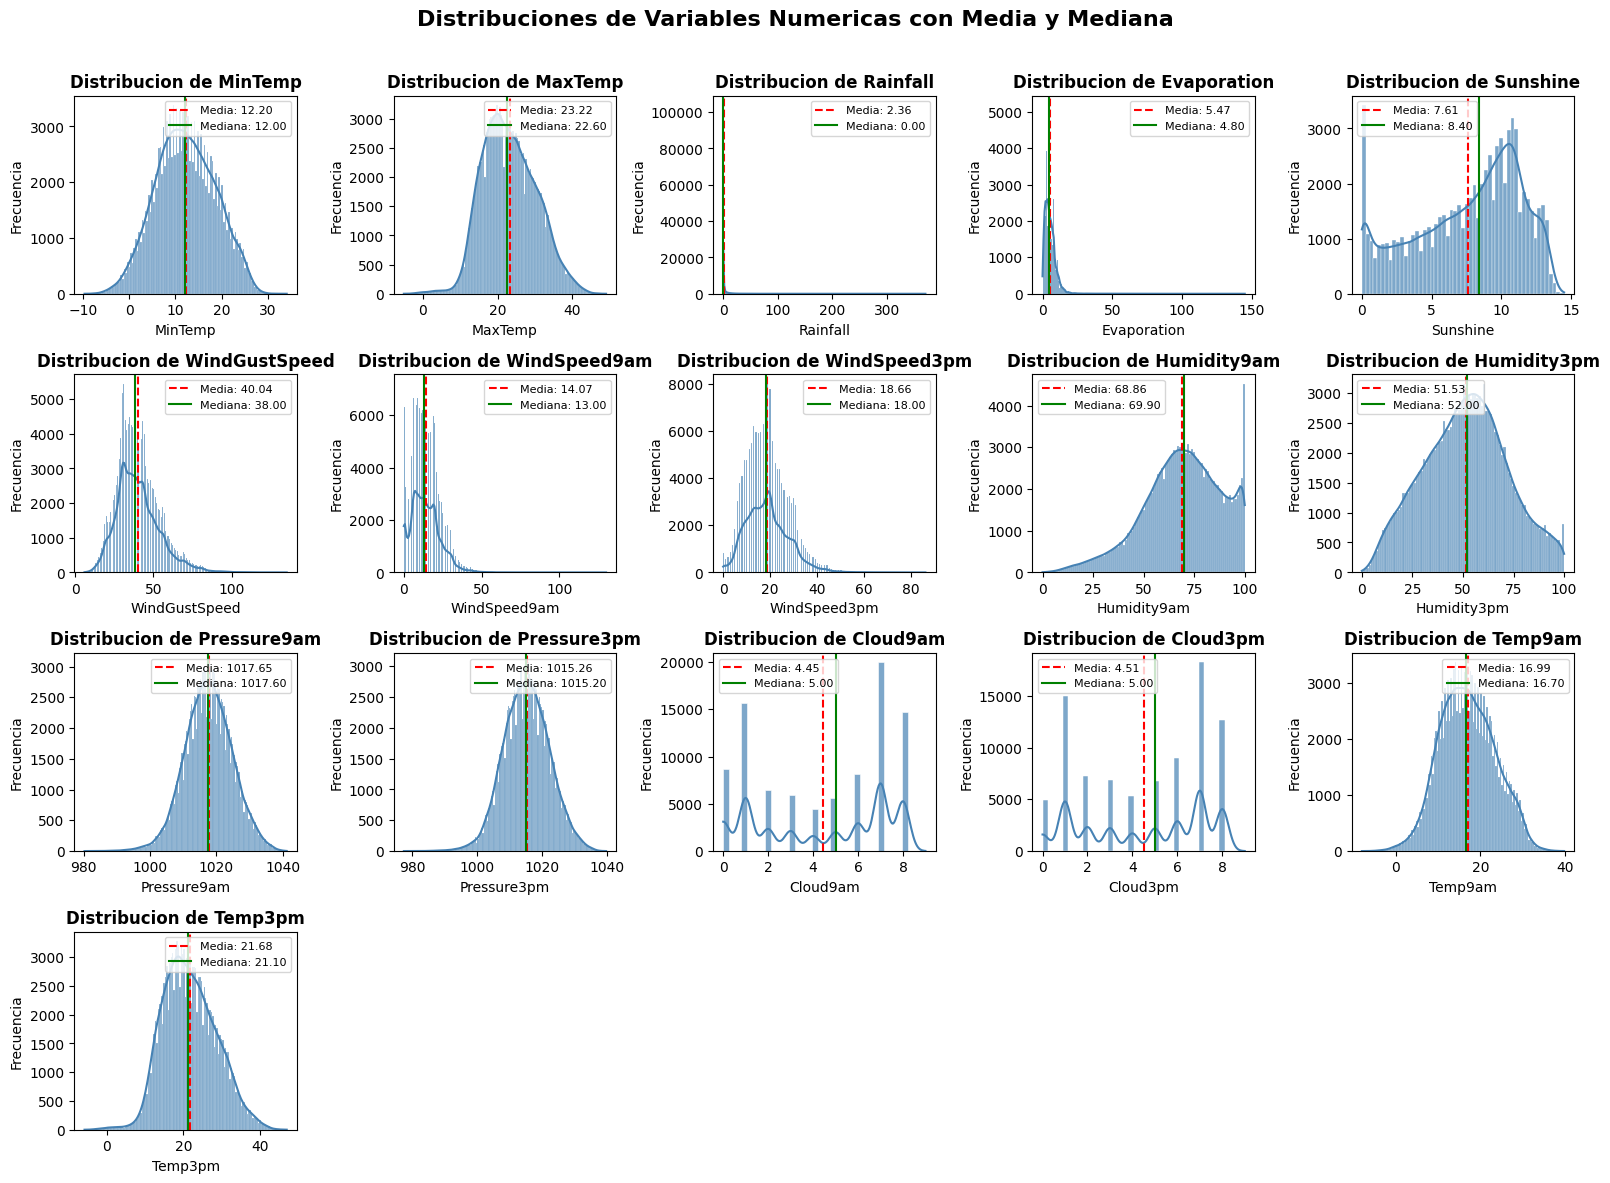

In [77]:
fig, axes = plt.subplots(5, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Interpretación

Temperaturas

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") presentan medias y medianas muy similares, lo que indica

distribuciones aproximadamente simétricas. El sesgo cercano a cero confirma esta simetría, mientras que la curtosis ligeramente

 negativa indica distribuciones sin colas extremas.

Además, el coeficiente de variación es moderado (30%–50%), lo que refleja una variabilidad esperable en este tipo de mediciones.

Se trata de variables estables y bien comportadas.


Rainfall

La variable "Rainfall" presenta una gran diferencia entre la media (2.36) y la mediana (0), lo que indica una fuerte asimetría.

El coeficiente de variación es extremadamente alto (359%), y el sesgo (9.83) junto con la curtosis (178) confirman una distribución

altamente sesgada con valores extremos.

Esto refleja que la mayoría de los días no llueve, pero cuando ocurre esto, puede haber precipitaciones muy intensas.

Se trata de una variable con alta variabilidad y presencia de outliers.


Evaporation y Sunshine

Las variables "Evaporation" y "Sunshine" presentan cierta asimetría, especialmente "Evaporation", donde la media es mayor que la

mediana y el sesgo es elevado.

El coeficiente de variación en ambas variables es relativamente alto, indicando una variabilidad considerable.

Tambien, "Evaporation" muestra una curtosis alta, lo que sugiere la presencia de valores extremos.


Viento

Las variables de viento ("WindGustSpeed", "WindSpeed9am", "WindSpeed3pm") presentan un sesgo positivo moderado, lo que indica que

existen algunos valores altos poco frecuentes.

Las medias son ligeramente superiores a las medianas, lo cual refuerza esta asimetría.

El coeficiente de variación es moderado a alto, reflejando variabilidad en la intensidad del viento.

Esto es consistente con la presencia ocasional de ráfagas fuertes.


Humedad

Las variables de humedad ("Humidity9am", "Humidity3pm") presentan medias y medianas muy cercanas, lo que indica distribuciones

simétricas.

El sesgo es cercano a cero y la curtosis indica ausencia de colas extremas.

El coeficiente de variación es moderado, lo que sugiere una variabilidad normal en las condiciones de humedad.


Presión

Las variables de presión ("Pressure9am", "Pressure3pm") presentan medias y medianas prácticamente iguales, indicando distribuciones

altamente simétricas.

El coeficiente de variación es muy bajo (<1%), lo que muestra una gran estabilidad en estas mediciones.

El sesgo y la curtosis cercanos a cero refuerzan que son variables bien distribuidas y sin valores extremos.


Nubosidad

Las variables "Cloud9am" y "Cloud3pm" presentan medias cercanas a la mediana, aunque con leve asimetría negativa.

El coeficiente de variación es alto, lo que indica dispersión en los niveles de nubosidad.

La curtosis negativa sugiere distribuciones más planas, sin concentración fuerte en valores centrales.

Cabe destacar que estas variables son discretas (valores entre 0 y 9).



En general, se observa que variables como temperatura y presión presentan comportamientos estables y simétricos, mientras que

variables como "Rainfall" y "Evaporation" muestran alta variabilidad y asimetría, lo cual es consistente con fenómenos climáticos

reales.

Estas diferencias serán relevantes al momento de aplicar técnicas de preprocesamiento y modelado.

### Distribución de Variables Categóricas

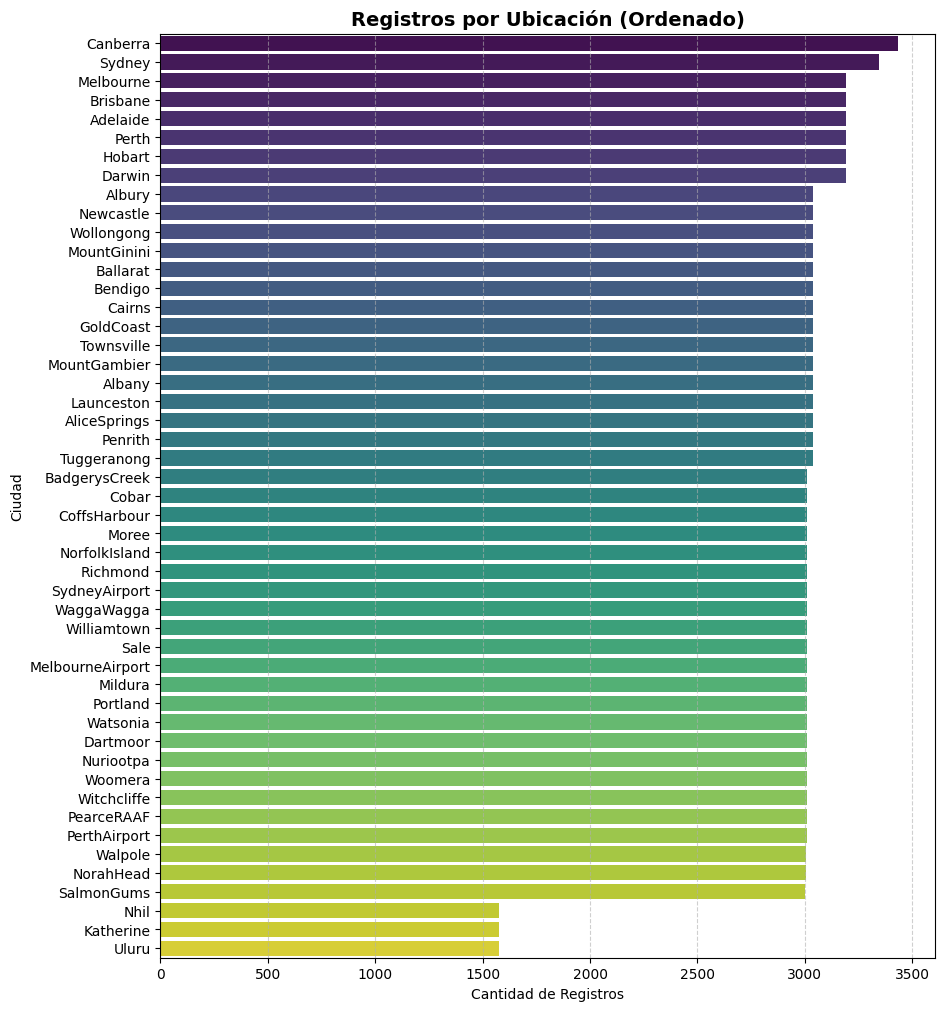

In [78]:
plt.figure(figsize=(10, 12))

# Location en eje Y
sns.countplot(y='Location', data=df, palette='viridis',
              order=df['Location'].value_counts().index)

plt.title('Registros por Ubicación (Ordenado)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Registros')
plt.ylabel('Ciudad')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

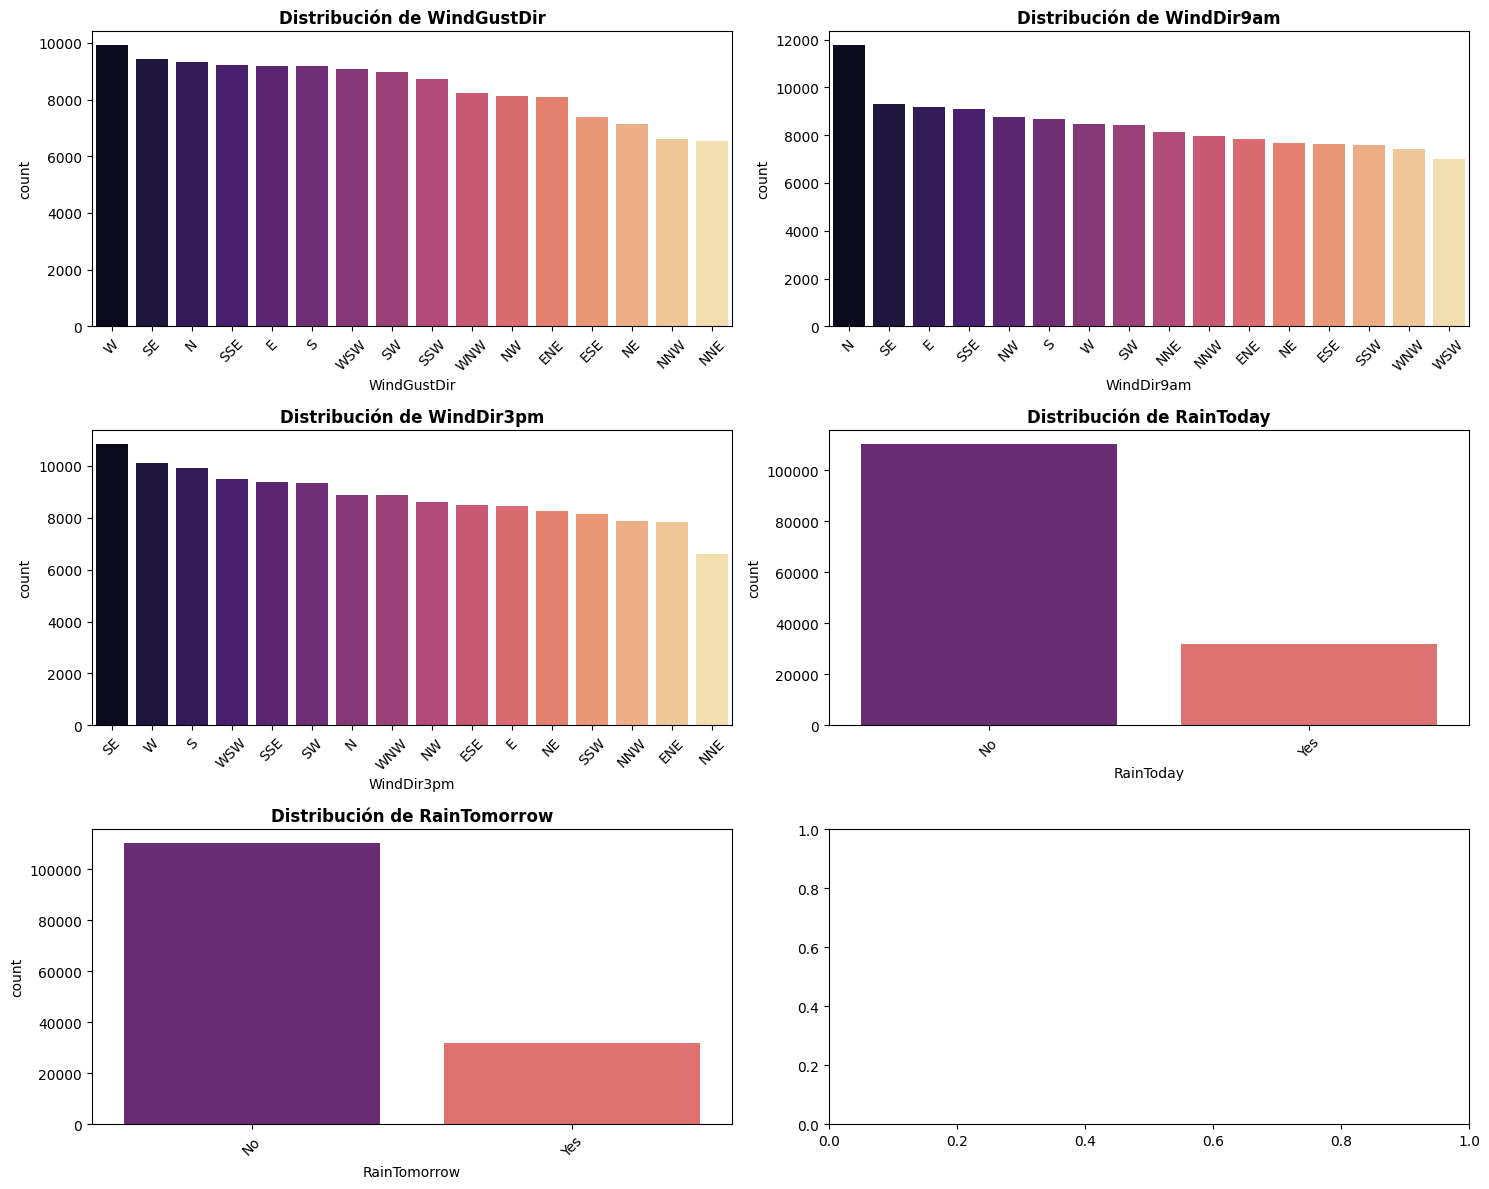

In [79]:
# Lista sin location
cols_sin_location = [col for col in cols_categoricas if col != 'Location']

# Crea el lienzo
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_sin_location):
    # Cuenta
    sns.countplot(x=col, data=df, ax=axes[i], palette='magma',
                  order=df[col].value_counts().index)

    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Interpretación de variables categóricas

Los gráficos muestran la distribución de las variables categóricas relacionadas con la dirección del viento y la presencia de lluvia.

Dirección del viento

Las variables "WindGustDir", "WindDir9am" y "WindDir3pm" presentan distribuciones relativamente equilibradas entre las distintas direcciones del viento.

Aunque aparecen con mayor frecuencia:
- En "WindGustDir" las direcciones "W" y "SE".
- En "WindDir9am" la dirección "N".
- En "WindDir3pm" las direcciones "SE" y "W".

Esto indica que ciertas direcciones del viento son más comunes en las ciudades analizadas.



RainToday

La variable "RainToday" muestra mayoría de la categoría "No".

Esto nos indica que en la mayoría de los días registrados, no hubo lluvia.



RainTomorrow

La variable objetivo "RainTomorrow" también presenta una mayoría de casos "No" respecto a "Yes".

Esto sugiere que el dataset se encuentra desbalanceado, ya que los días sin lluvia son considerablemente más frecuentes que los días con lluvia.

Este desbalance deberá tenerse en cuenta durante el entrenamiento y evaluación de los modelos de clasificación.

### Prueba de Normalidad

 Test D'Agostino-Pearson

In [80]:


ALPHA = 0.05
resultados = []

for col in cols_numericas:
    # Quitamos nulos solo para el test
    datos = df[col].dropna()

    # D'Agostino-Pearson
    stat, p_val = stats.normaltest(datos)

    resultados.append({
        'Variable': col,
        'Estadístico K2': f"{stat:.2f}",
        'p-valor': f"{p_val:.4f}",
        '¿Es Normal?': 'Si' if p_val > ALPHA else 'No'
    })

df_normalidad = pd.DataFrame(resultados)
print(df_normalidad)

         Variable Estadístico K2 p-valor ¿Es Normal?
0         MinTemp        2458.15  0.0000          No
1         MaxTemp        1494.61  0.0000          No
2        Rainfall      221533.93  0.0000          No
3     Evaporation       72314.38  0.0000          No
4        Sunshine       10184.00  0.0000          No
5   WindGustSpeed       16930.79  0.0000          No
6    WindSpeed9am       15322.02  0.0000          No
7    WindSpeed3pm        9441.56  0.0000          No
8     Humidity9am        5070.49  0.0000          No
9     Humidity3pm        2875.92  0.0000          No
10    Pressure9am         431.87  0.0000          No
11    Pressure3pm         124.72  0.0000          No
12       Cloud9am      491644.89  0.0000          No
13       Cloud3pm      594306.45  0.0000          No
14        Temp9am        1182.68  0.0000          No
15        Temp3pm        1413.24  0.0000          No


Optamos por el test de D'Agostino-Pearson porque combina el sesgo y la curtosis. Como el análisis descriptivo ya mostraba valores altos de curtosis en variables como Rainfall, este test valida formalmente de que no se puede asumir una distribución Gaussiana.

Al confirmar que ninguna variable es normal (p-valor < 0.05), justificamos técnicamente que en el preprocesamiento usaremos RobustScaler y para las correlaciones es preferible usar el coeficiente de Spearman sobre el de Pearson.

Dado el gran tamaño muestral del dataset, incluso pequeñas desviaciones respecto de la normalidad producen p-valores muy bajos. Por ello,
la decisión final se complementa con análisis visual (Q-Q plots).

### QQPLOTS

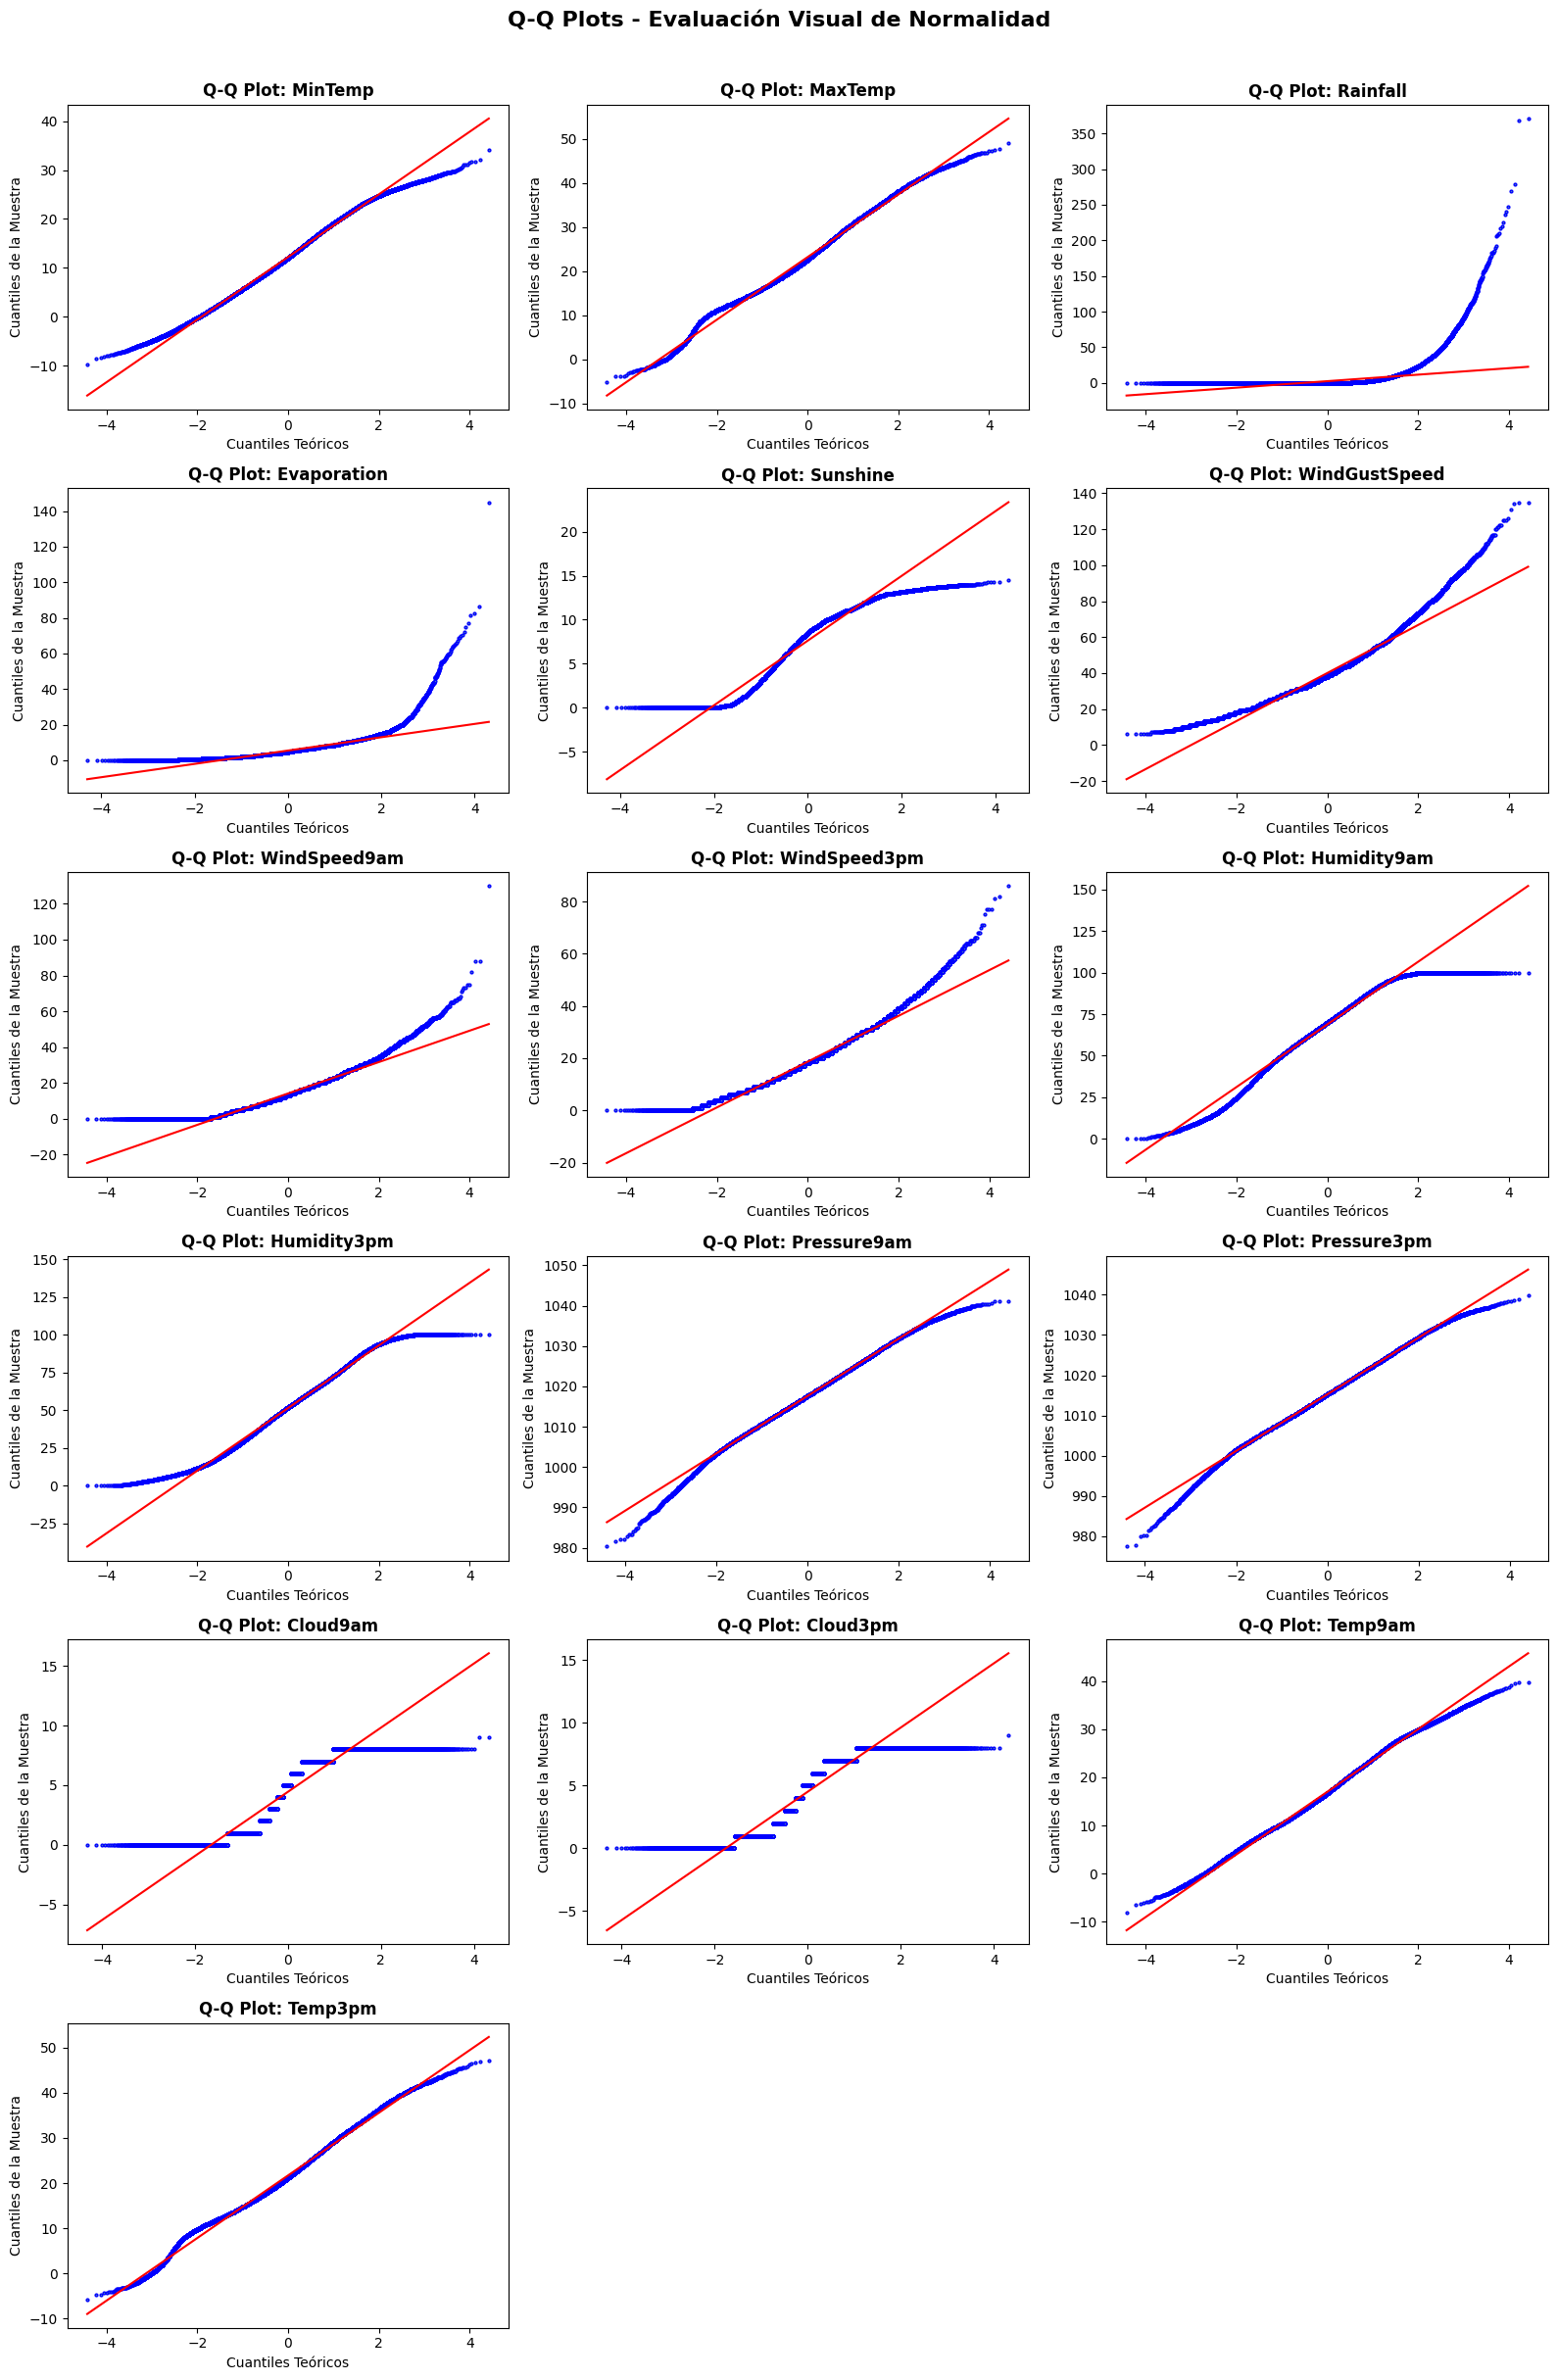

In [81]:
# Calculamos 3 columnas
n_cols = 3
n_rows = math.ceil(len(cols_numericas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    # quitamos nulos temporalmente
    datos = df[col].dropna()

    # Gráfico Q-Q
    stats.probplot(datos, dist='norm', plot=ax)


    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue') # Puntos
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red') # Línea de referencia
    ax.set_xlabel('Cuantiles Teóricos')
    ax.set_ylabel('Cuantiles de la Muestra')

# Desactivamos cuadros sobrantes
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluación Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") y presión ("Pressure9am", "Pressure3pm") muestran una distribución

aproximadamente normal, los puntos siguen relativamente bien la línea de referencia.

Las variables como "Rainfall", "Evaporation" y las velocidades de viento presentan fuertes desviaciones respecto de la línea roja, indicando distribuciones

asimétricas y presencia de valores extremos.

Las variables "Cloud9am" y "Cloud3pm" muestran patrones escalonados debido a que son variables discretas.

Las variables de Humedad presentan una distribución parcialmente simétrica, aunque con desviaciones en los extremos.

En general, observamos que no todas las variables siguen una distribución normal, especialmente aquellas relacionadas con fenómenos climáticos extremos

como lluvia y viento.

### Gestion de datos: Nulos, Duplicados, Consistencia

 Registros Nulos

In [82]:
# Verificamos si hay filas nulas
df.isna().all(axis=1).any()

np.False_

In [83]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
               Nulos  Porcentaje (%)            Tipo
Date               0        0.000000  datetime64[us]
Location           0        0.000000             str
MinTemp         1484        1.020549         float64
MaxTemp         1253        0.861690         float64
Rainfall        3260        2.241906         float64
Evaporation    62754       43.155998         float64
Sunshine       69796       47.998790         float64
WindGustDir    10316        7.094325             str
WindGustSpeed  10253        7.051000         float64
WindDir9am     10562        7.263500             str
WindDir3pm      4226        2.906225             str
WindSpeed9am    1767        1.215168         float64
WindSpeed3pm    3061        2.105053         float64
Humidity9am     2653        1.824471         float64
Humidity3pm     4505        3.098094         float64
Pressure9am    15061       10.357467         float64
Pressure3pm    15024       10.332022         float64
Cloud9am       55870

In [84]:
col_nulos = pct_nulos[pct_nulos>0].sort_values(ascending=False)

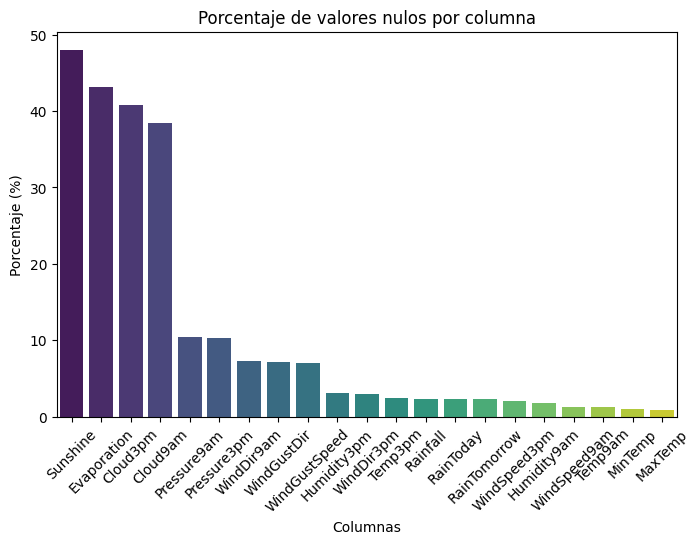

In [85]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Patrones de datos faltantes

Podemos observar que las variables con mas datos nulos son Sunshine, Evaporation, Cloud3pm y Cloud9am con mas del 35%.

No parecería un patrón completamente aleatorio (MCAR), ya que la cantidad de datos faltantes es muy alta. Se consideraría más

razonable asumir los datos faltantes del tipo MAR (Missing At Random), donde la ausencia de datos puede depender de otras variables

observadas del dataset, como la ubicación ("Location") o la fecha ("Date").

Se evaluarán estrategias de imputación adecuadas segun el tipo de variable y el porcentaje de datos faltantes.



### Registros duplicados

In [86]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: No conservar duplicados 
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: En datos meteorológicos, cada registro representa una observación única \n'
          'en Ubicación/Fecha. La existencia de filas exactamente iguales \n'
          'indica una redundancia de datos o errores en la \n'
          'consolidación del dataset, y no eventos atmosféricos independientes.')
else:
    print('No se detectaron registros duplicados. La integridad temporal y espacial es correcta.')

Registros duplicados: 0 (0.00%)

No se detectaron registros duplicados. La integridad temporal y espacial es correcta.


### Registros inconsistentes

In [87]:
# Definimos las reglas lógicas
error_temp    = df['MinTemp'] > df['MaxTemp']
error_lluvia  = df['Rainfall'] < 0
error_humedad = (df['Humidity9am'] > 100) | (df['Humidity3pm'] > 100)
error_viento  = (df['WindGustSpeed'] < 0) | (df['WindSpeed9am'] < 0) | (df['WindSpeed3pm'] < 0)

# Aplicamos el reemplazo por NaN columna por columna
df.loc[error_temp, ['MinTemp', 'MaxTemp']] = np.nan
df.loc[error_lluvia, 'Rainfall'] = np.nan
df.loc[df['Humidity9am'] > 100, 'Humidity9am'] = np.nan
df.loc[df['Humidity3pm'] > 100, 'Humidity3pm'] = np.nan
df.loc[df['WindGustSpeed'] < 0, 'WindGustSpeed'] = np.nan
df.loc[df['WindSpeed9am'] < 0, 'WindSpeed9am'] = np.nan
df.loc[df['WindSpeed3pm'] < 0, 'WindSpeed3pm'] = np.nan

# Auditamos las columnas
cols_audit = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
              'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

print(f'\nNuevos nulos:')
print(df[cols_audit].isnull().sum().to_dict())

print("\nDECISIÓN: No se eliminaron filas. Los datos erróneos o repetidos se marcaron como NaN "
      "para ser reparados en la etapa de imputación.")


Nuevos nulos:
{'MinTemp': 1554, 'MaxTemp': 1323, 'Rainfall': 3260, 'Humidity9am': 2653, 'Humidity3pm': 4505, 'WindGustSpeed': 10253, 'WindSpeed9am': 1767, 'WindSpeed3pm': 3061}

DECISIÓN: No se eliminaron filas. Los datos erróneos o repetidos se marcaron como NaN para ser reparados en la etapa de imputación.


### Análisis de Balanceo de Clases

In [88]:
# Analizamos el Target
target = 'RainTomorrow'
conteo = df[target].value_counts()
ir = conteo.max() / conteo.min()

print(f'DIAGNÓSTICO DEL TARGET: {target}')
print('=' * 40)
print(f'Clase mayoritaria (No llueve): {conteo.max()}')
print(f'Clase minoritaria (Sí llueve): {conteo.min()}')
print(f'Imbalance Ratio (IR): {ir:.2f}')

# Criterios de decisión
if ir > 5:
    status = "ALTO"
elif ir > 2.5:
    status = "MODERADO"
else:
    status = "ACEPTABLE"

print(f'Resultado: Desbalanceo {status}')
print('=' * 40)

DIAGNÓSTICO DEL TARGET: RainTomorrow
Clase mayoritaria (No llueve): 110281
Clase minoritaria (Sí llueve): 31872
Imbalance Ratio (IR): 3.46
Resultado: Desbalanceo MODERADO


Interpretación: Por cada día que llueve (Yes), hay aproximadamente 3.5 días en los que no llueve (No).

In [89]:
for col in cols_categoricas:
    conteo = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    clase_mayor = conteo.idxmax()
    clase_menor = conteo.idxmin()
    ir = conteo.max() / conteo.min()

    print(f'Variable: {col}')
    print('-' * 40)

    for cat in conteo.index:
        print(f'  {str(cat):>12s}: {conteo[cat]:>6d} ({pct[cat]:.2f}%)')

    print(f'  Clase mayoritaria: {clase_mayor} ({conteo.max()})')
    print(f'  Clase minoritaria: {clase_menor} ({conteo.min()})')
    print(f'  Imbalance Ratio (IR): {ir:.2f}')

    if ir > 5:
        print(f'  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.')
    elif ir > 2.5:
        print(f'  >> ATENCION: Desbalanceo moderado (IR > 2.5).')
    else:
        print(f'  >> Balanceo aceptable.')
    print()

Variable: Location
----------------------------------------
      Canberra:   3435 (2.36%)
        Sydney:   3343 (2.30%)
     Melbourne:   3192 (2.20%)
      Brisbane:   3192 (2.20%)
      Adelaide:   3192 (2.20%)
         Perth:   3192 (2.20%)
        Hobart:   3192 (2.20%)
        Darwin:   3192 (2.20%)
        Albury:   3039 (2.09%)
     Newcastle:   3039 (2.09%)
    Wollongong:   3039 (2.09%)
   MountGinini:   3039 (2.09%)
      Ballarat:   3039 (2.09%)
       Bendigo:   3039 (2.09%)
        Cairns:   3039 (2.09%)
     GoldCoast:   3039 (2.09%)
    Townsville:   3039 (2.09%)
  MountGambier:   3039 (2.09%)
        Albany:   3039 (2.09%)
    Launceston:   3039 (2.09%)
  AliceSprings:   3039 (2.09%)
       Penrith:   3038 (2.09%)
   Tuggeranong:   3038 (2.09%)
  BadgerysCreek:   3008 (2.07%)
         Cobar:   3008 (2.07%)
  CoffsHarbour:   3008 (2.07%)
         Moree:   3008 (2.07%)
  NorfolkIsland:   3008 (2.07%)
      Richmond:   3008 (2.07%)
  SydneyAirport:   3008 (2.07%)
    Wag

Las variables Location y Direcciones del Viento tienen un Balanceo Aceptable (IR entre 1.51 y 2.18).

Location (IR 2.18): La mayoría de las ciudades representan aprox. 2% del dataset. Tambien observamos que Nhil, Katherine y Uluru tienen la mitad de

registros (aprox. 1%) que las ciudades principales. Esto sugiere que esas estaciones meteorológicas fueron instaladas más tarde o reportaron datos por

menos tiempo.

Direcciones del Viento (IR ~1.6): Las direcciones están muy bien repartidas. No hay un viento que predomine de forma masiva sobre los demás, lo cual es

ideal para que el modelo aprenda la influencia de todas las direcciones por igual.

La Simetría entre RainToday y RainTomorrow es de IR (3.46) y porcentajes casi idénticos (77.58%). Esto indica una consistencia muy alta en el

dataset. La probabilidad de que llueva "hoy" es la misma que la de "mañana" estadísticamente, lo que confirma que estamos ante un fenómeno climático

estable en el tiempo.

### Análisis de Correlaciones y Colinealidad

Utilizaremos el Spearman por:

Falta de Normalidad: las pruebas de  D'Agostino-Pearson rechazaron la hipótesis nula de normalidad (p < 0.05) para todas las variables numéricas.

Presencia de Outliers Extremos: Variables como Rainfall mostraron una curtosis de +178.1, lo que indica "colas pesadas" o valores muy extremos (outliers).

Spearman es mucho más robusto ante outliers porque trabaja con rangos en lugar de valores exactos.

Relaciones No Lineales: En meteorología, muchas relaciones son monótonas (cuando una sube, la otra también) pero no necesariamente en línea recta. Spearman

captura estas relaciones que Pearson ignoraría o subestimaría.

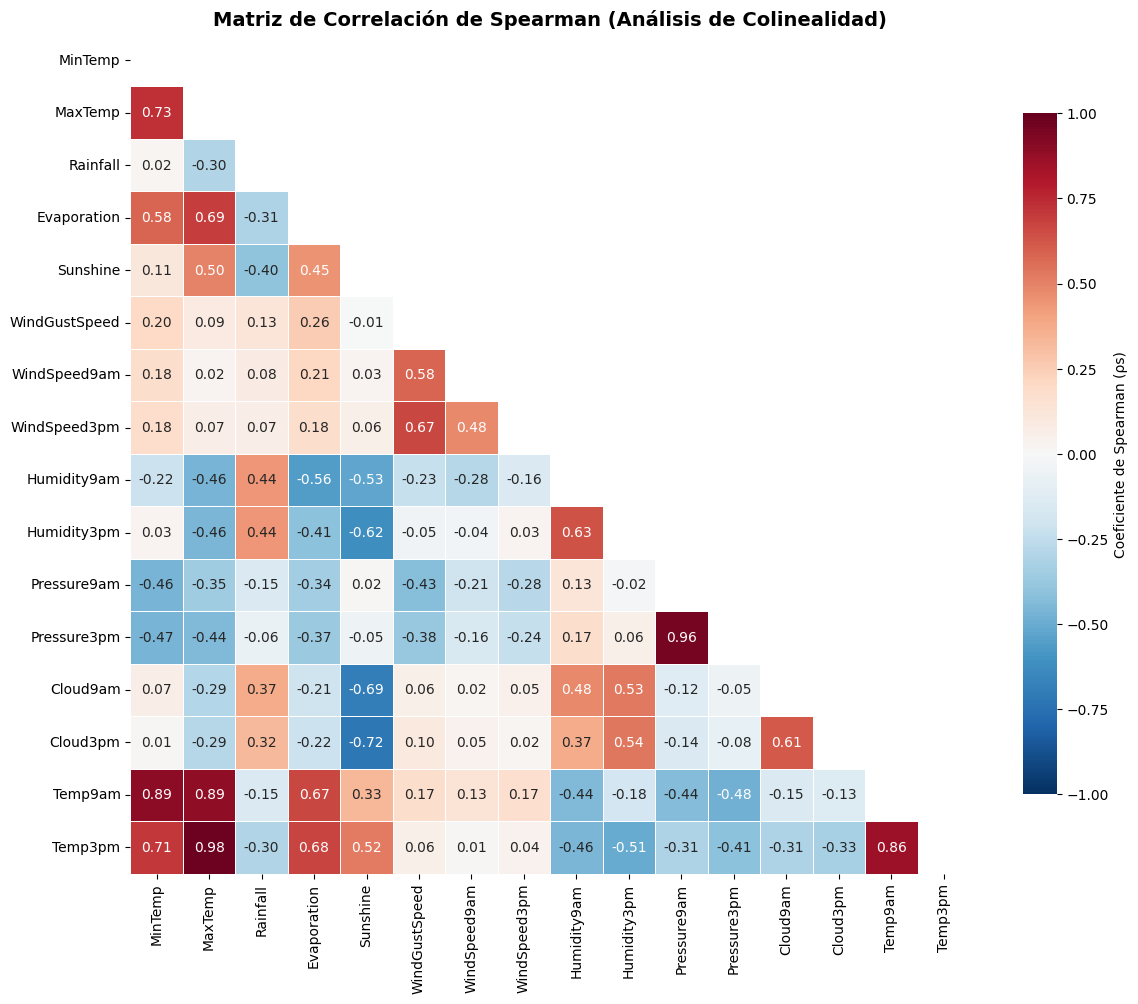

In [90]:
#  Calculamos la matriz usando Spearman
corr_spearman = df[cols_numericas].corr(method='spearman')

#  Máscara triangular
# np.triu crea una matriz de unos en la parte superior y la usamos para "tapar"
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman (ρs)'})

ax.set_title('Matriz de Correlación de Spearman (Análisis de Colinealidad)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se observan correlaciones positivas altas entre variables relacionadas con temperatura:

"MaxTemp" y "Temp3pm" (0.98)
"MinTemp" y "Temp9am" (0.89)
"Temp9am" y "MaxTemp" (0.89)

Esto indica que estas variables contienen información muy similar.

También se observan correlaciones negativas entre humedad y temperatura, lo que sugiere que a mayor temperatura suele disminuir la humedad relativa.

Por otro lado, las variables de presión ("Pressure9am" y "Pressure3pm") presentan una correlación extremadamente alta (0.96), indicando una fuerte relación

entre ambas mediciones.

En general, las correlaciones observadas son coherentes con el comportamiento esperado de variables meteorológicas.

In [91]:
# Interpretaciones
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |Spearman| >= {UMBRAL_COLINEALIDAD} (Colinealidad detectada):')
print('=' * 65)

pares_colineales = []

for i in range(len(corr_spearman.columns)):
    for j in range(i + 1, len(corr_spearman.columns)):
        r = corr_spearman.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_spearman.columns[i]
            var2 = corr_spearman.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: ρs = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).')
    print('Decisión: Estas variables son redundantes. Evaluaremos eliminar o usar PCA.')

Pares con |Spearman| >= 0.85 (Colinealidad detectada):
  MinTemp <-> Temp9am: ρs = 0.8935
  MaxTemp <-> Temp9am: ρs = 0.8866
  MaxTemp <-> Temp3pm: ρs = 0.9791
  Pressure9am <-> Pressure3pm: ρs = 0.9577
  Temp9am <-> Temp3pm: ρs = 0.8590

Se detectaron 5 par(es) colineal(es).
Decisión: Estas variables son redundantes. Evaluaremos eliminar o usar PCA.


### VIF

In [92]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

   Temp3pm: VIF =      37.96  << SEVERA
   MaxTemp: VIF =      32.90  << SEVERA
   Temp9am: VIF =      20.42  << SEVERA
  Pressure3pm: VIF =      18.47  << SEVERA
  Pressure9am: VIF =      18.45  << SEVERA
   MinTemp: VIF =       9.82  << MODERADA
  Humidity3pm: VIF =       5.90  << MODERADA
  Humidity9am: VIF =       3.98
  Sunshine: VIF =       3.32
  WindGustSpeed: VIF =       2.82
  Cloud3pm: VIF =       2.28
  Cloud9am: VIF =       2.24
  Evaporation: VIF =       2.21
  WindSpeed3pm: VIF =       2.11
  WindSpeed9am: VIF =       1.84
  Rainfall: VIF =       1.17


Colinealidad Severa (VIF > 10). Significa que estas variables están "explicadas" por las demás y son redundantes para el aprendizaje del modelo.


Temp3pm, MaxTemp, Temp9am: Presentan los valores más altos (VIF entre 20 y 38). Estas medidas estadísticamente están altamente correlacionadas entre sí.

Pressure3pm, Pressure9am: Ambos tienen un VIF de aproximadamente 18.5. Son variables "espejo" que aportan información redundante.

### Visualización variables VIF

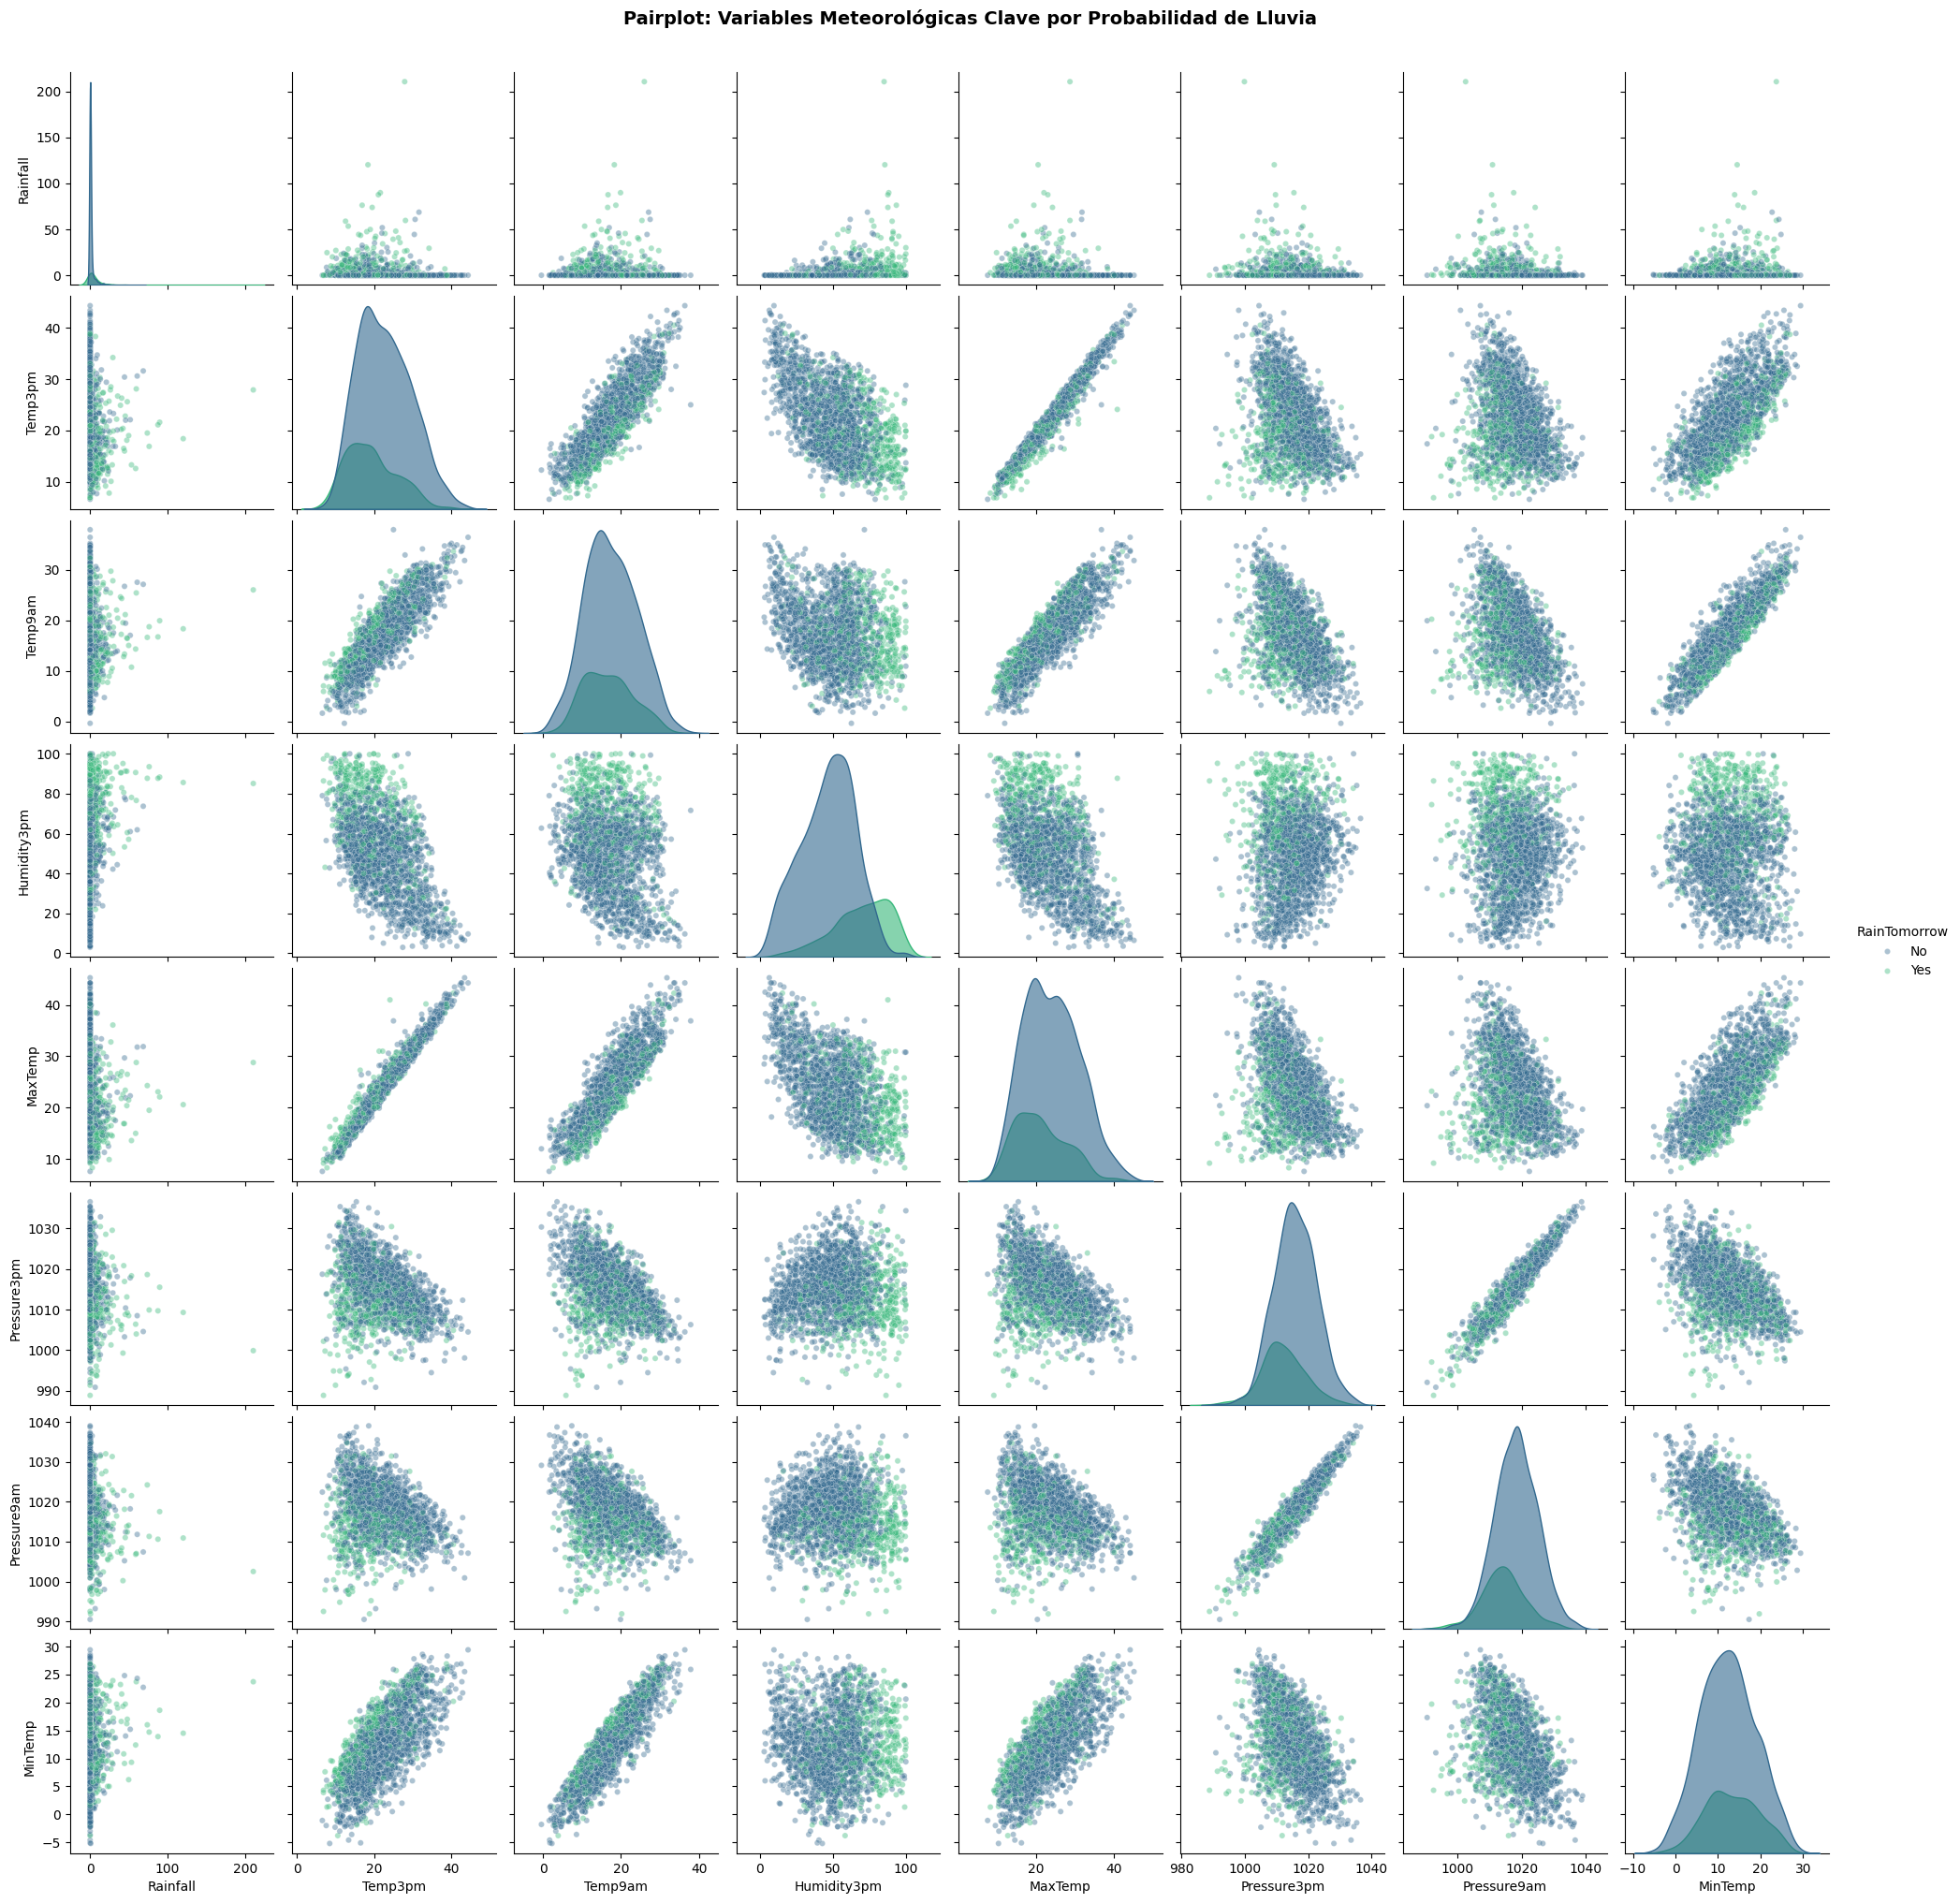

In [93]:
#  Variables basadas en el análisis de VIF
vars_analisis = ['Rainfall', 'Temp3pm', 'Temp9am', 'Humidity3pm', 'MaxTemp', 'Pressure3pm', 'Pressure9am', 'MinTemp']
target = 'RainTomorrow'

#  Pairplot
# Usamos una muestra
g = sns.pairplot(df[vars_analisis + [target]].dropna().sample(2000, random_state=42),
                 hue=target,
                 palette='viridis',
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kws={'alpha': 0.6})

# Visualización
g.figure.suptitle('Pairplot: Variables Meteorológicas Clave por Probabilidad de Lluvia',
                  fontsize=14, fontweight='bold', y=1.02)

plt.show()

Se observa que los casos donde sí llueve ("Yes") suelen estar asociados con:
- mayores valores de "Rainfall"
- mayor humedad ("Humidity3pm")
- menores valores de presión ("Pressure3pm")
- temperaturas máximas más bajas ("MaxTemp")

También, se identifican relaciones inversas entre algunas variables, por ejemplo:
- a mayor temperatura máxima, menor humedad
- a mayor presión, menor probabilidad de lluvia


También se aprecia una fuerte relación entre variables de temperatura (`MinTemp`, `Temp9am`, `Temp3pm` y `MaxTemp`), ya que aumentan o disminuyen de forma similar.

Además, las variables de presión muestran una relación positiva muy fuerte entre sí, mientras que la humedad presenta una relación inversa con la temperatura.

En general, las observaciones con lluvia y sin lluvia muestran diferencias en algunas variables, lo que indica que estas pueden ser útiles para predecir si lloverá al día siguiente.

### Detección de Outliers

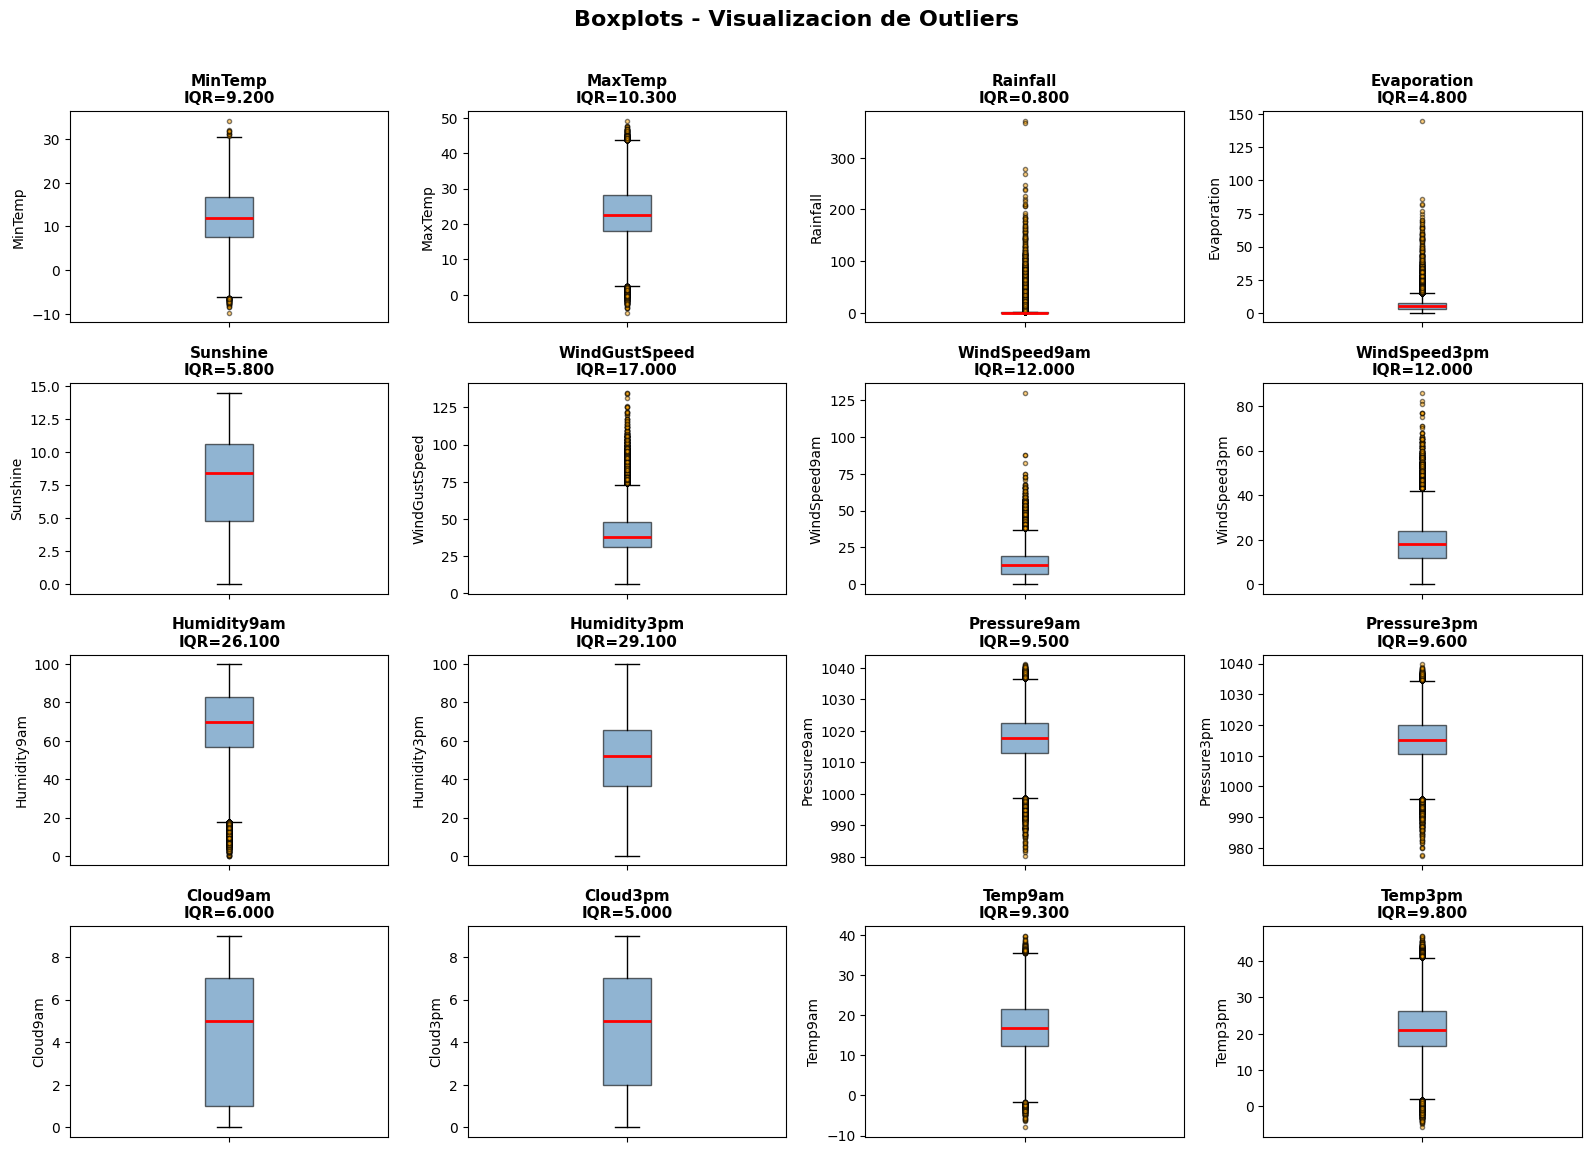

In [94]:
fig, axes = plt.subplots(5, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se observa que variables "Rainfall", "Evaporation", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm" presentan una gran cantidad de outliers y

distribuciones asimétricas, especialmente hacia valores altos.

Se observa que variables como "MinTemp", "MaxTemp", "Pressure3pm" y "Pressure9am" muestran distribuciones más estables y con menor cantidad de valores extremos.

En general, los outliers observados son coherentes con fenómenos meteorológicos extremos y no necesariamente representan errores en los datos.

### División Train-Test

In [95]:
# Eliminamos los nulos de la variable target
df = df.dropna(subset=['RainTomorrow'])

# Definimos X e y
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

In [96]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 113722 entries, 63909 to 61794
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           113722 non-null  datetime64[us]
 1   Location       113722 non-null  str           
 2   MinTemp        113155 non-null  float64       
 3   MaxTemp        113415 non-null  float64       
 4   Rainfall       112582 non-null  float64       
 5   Evaporation    65008 non-null   float64       
 6   Sunshine       59396 non-null   float64       
 7   WindGustDir    106279 non-null  str           
 8   WindGustSpeed  106328 non-null  float64       
 9   WindDir9am     105664 non-null  str           
 10  WindDir3pm     110649 non-null  str           
 11  WindSpeed9am   112641 non-null  float64       
 12  WindSpeed3pm   111587 non-null  float64       
 13  Humidity9am    112295 non-null  float64       
 14  Humidity3pm    110806 non-null  float64       
 15  Pressure9am  

### Feature Engineering

Creamos la variable 'Season' adaptada al hemisferio sur para capturar la estacionalidad australiana, y variables de interacción como el 'TempRange' y

'HumDiff'. Estas son fundamentales porque el gradiente de humedad y la amplitud térmica diaria son indicadores físicos de inestabilidad atmosférica mucho

más potentes que las mediciones aisladas de la mañana o la tarde.

In [97]:
# funcion
def aplicar_ingenieria_variables(df):

    df = df.copy()

    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month

    # Mapeo según el hemisferio sur
    season_map = {
        12: 'Summer', 1: 'Summer', 2: 'Summer',
        3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
        6: 'Winter', 7: 'Winter', 8: 'Winter',
        9: 'Spring', 10: 'Spring', 11: 'Spring'
    }
    df['Season'] = df['Month'].map(season_map)

    # Variables de Amplitud térmica

    df['TempRange'] = df['MaxTemp'] - df['MinTemp']

    # Interacción de Humedad

    df['HumDiff'] = df['Humidity3pm'] - df['Humidity9am']

    # Diferencia de Presión

    df['PressureDiff'] = df['Pressure3pm'] - df['Pressure9am']

    return df


X_train = aplicar_ingenieria_variables(X_train.copy())
X_test = aplicar_ingenieria_variables(X_test.copy())

# ACTUALIZACIÓN DE LISTAS

# Se agrega season
if 'Season' not in cols_categoricas:
    cols_categoricas.append('Season')

# Agregamos las nuevas numéricas
nuevas_num = ['TempRange', 'HumDiff', 'PressureDiff']
for col in nuevas_num:
    if col in X_train.columns and col not in cols_numericas:
        cols_numericas.append(col)

print("Feature Engineering exitoso.")
print(f"Columnas actuales: {X_train.shape[1]}")

Feature Engineering exitoso.
Columnas actuales: 27


In [98]:
# Variables para eliminar

cols_redundantes = ['Date', 'Month']

X_train = X_train.drop(columns=cols_redundantes)
X_test = X_test.drop(columns=cols_redundantes)

In [99]:
# Separamos listas de columnas por tipo
cols_num = X_train.select_dtypes(include=[np.number]).columns.tolist()
cols_cat = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

### Imputación de datos

Imputación de columnas categóricas por la moda

In [100]:
imp_cat = SimpleImputer(strategy='most_frequent')
X_train[cols_cat] = imp_cat.fit_transform(X_train[cols_cat])
X_test[cols_cat] = imp_cat.transform(X_test[cols_cat])

Visualizacion de outliers y toma de decisión

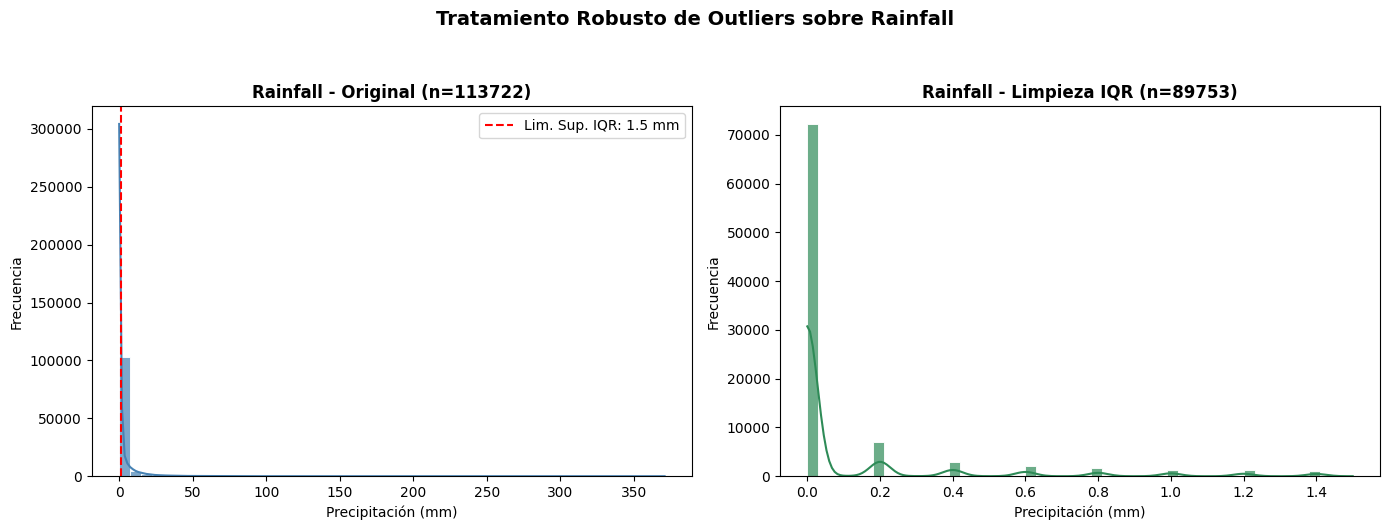

Análisis de Rainfall:
  - Registros considerados outliers: 23969
  - Porcentaje de limpieza: 21.08%


In [101]:
# Elegimos una columna con muchos outliers
col_ejemplo = 'Rainfall'
IQR_FACTOR = 1.5

# Tomamos datos sin nulos
datos = X_train[col_ejemplo]

# Cálculo de Límites Robustos (IQR)
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

# Filtrado para la visualización
datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Con Outliers
sns.histplot(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7, ax=axes[0], kde=True)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.1f} mm')
axes[0].set_title(f'{col_ejemplo} - Original (n={len(datos)})', fontweight='bold')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Gráfico 2: Sin Outliers (Efecto de la Limpieza)
sns.histplot(datos_sin_outliers, bins=50, color='seagreen', edgecolor='white', alpha=0.7, ax=axes[1], kde=True)
axes[1].set_title(f'{col_ejemplo} - Limpieza IQR (n={len(datos_sin_outliers)})', fontweight='bold')
axes[1].set_xlabel('Precipitación (mm)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Tratamiento Robusto de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Resumen
eliminados = len(datos) - len(datos_sin_outliers)
print(f'Análisis de {col_ejemplo}:')
print(f'  - Registros considerados outliers: {eliminados}')
print(f'  - Porcentaje de limpieza: {(eliminados / len(datos)) * 100:.2f}%')

Tomamos la decisión de no eliminar estos registros porque al hacerlo eliminaría la variabilidad más importante de nuestro target (los días de lluvia). En

su lugar, optamos por un RobustScaler, que utiliza la mediana y el rango intercuartílico para normalizar los datos, permitiendo que el modelo aprenda de

estos valores extremos sin que su magnitud distorsione los pesos del algoritmo de clasificación".

### Escalado

In [102]:
# Indispensable porque vamos a imputar con KNN
scaler = RobustScaler()
X_train_num_scaled = scaler.fit_transform(X_train[cols_num])
X_test_num_scaled = scaler.transform(X_test[cols_num])

Visualizamos el efecto del escalado

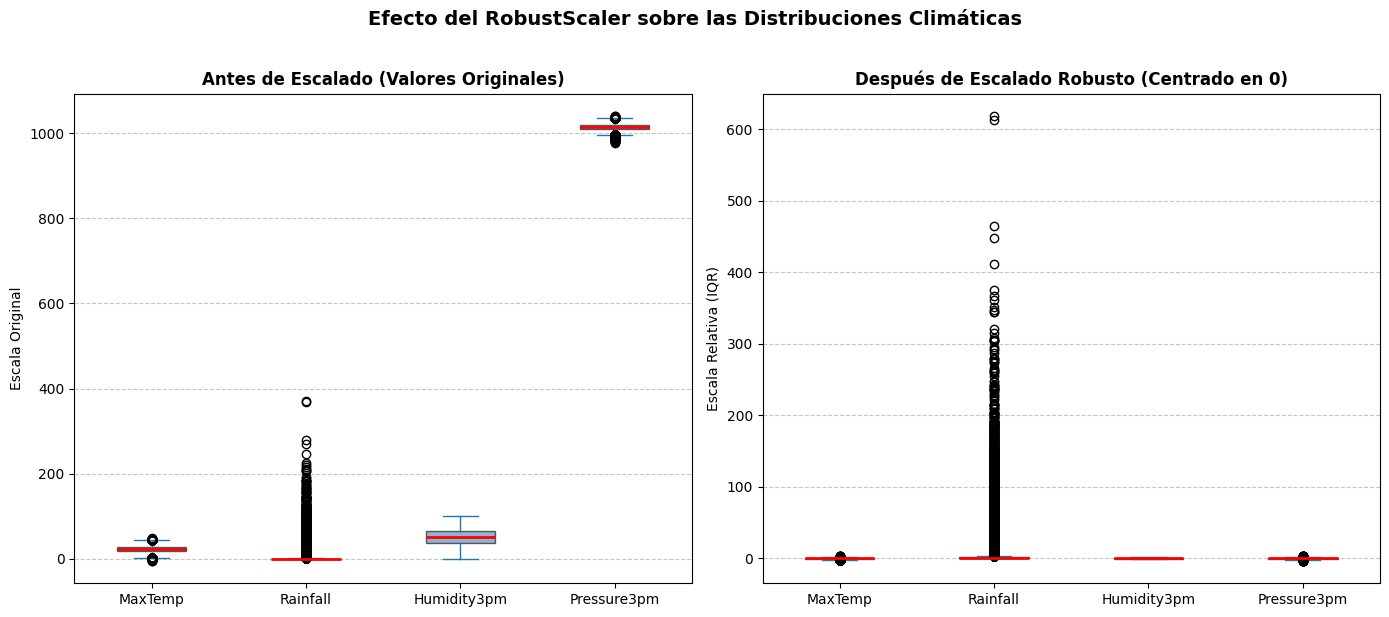

In [103]:
df_scaled_temp = pd.DataFrame(X_train_num_scaled, columns=cols_num, index=X_train.index)

# Variables que queremos mirar
vars_box = ['MaxTemp', 'Rainfall', 'Humidity3pm', 'Pressure3pm']

# Asegurarnos de que las variables existan en la lista 
vars_box = [v for v in vars_box if v in cols_num]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GRÁFICO 1: ANTES (Valores Originales de X_train)
X_train[vars_box].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))

axes[0].set_title('Antes de Escalado (Valores Originales)', fontweight='bold')
axes[0].set_ylabel('Escala Original')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# GRÁFICO 2: DESPUÉS (Valores Escalados usando nuestro DataFrame temporal)
# Reemplazamos X_train_num_scaled por df_scaled_temp
df_scaled_temp[vars_box].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))

axes[1].set_title('Después de Escalado Robusto (Centrado en 0)', fontweight='bold')
axes[1].set_ylabel('Escala Relativa (IQR)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Efecto del RobustScaler sobre las Distribuciones Climáticas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Liberamos memoria borrando el dataframe temporal
del df_scaled_temp

### Imputación por KNN

In [104]:
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    
# FIT con submuestra de 5000 (Probamos con todas las filas y explotó)
np.random.seed(42)
indices_muestra = np.random.choice(X_train_num_scaled.shape[0], size=5000, replace=False)
muestra_entrenamiento = X_train_num_scaled[indices_muestra, :]
    
knn_imputer.fit(muestra_entrenamiento)
    
# FUNCIÓN DE PROCESAMIENTO POR LOTES (Batching)
def transformar_en_lotes(imputer, X_scaled, batch_size=1000):
    """Pasamos los datos por el imputer en pequeños bloques para cuidar la RAM"""
    # Matriz vacía para guardar los resultados
    X_imputed = np.zeros_like(X_scaled)
    total_rows = X_scaled.shape[0]
        
    # Iteramos de a 'batch_size' filas
    for i in range(0, total_rows, batch_size):
        fin = min(i + batch_size, total_rows)
        # Transformamos solo una parte  y lo guardamos
        X_imputed[i:fin] = imputer.transform(X_scaled[i:fin]) 
            
    return X_imputed

X_train_num_imputed = transformar_en_lotes(knn_imputer, X_train_num_scaled, batch_size=1000)
    
X_test_num_imputed = transformar_en_lotes(knn_imputer, X_test_num_scaled, batch_size=1000)
    
# RECONSTRUCCIÓN DEL DATAFRAME
X_train[cols_num] = X_train_num_imputed
X_test[cols_num] = X_test_num_imputed


Gráfico para visualizar "antes" y "despues" de imputar

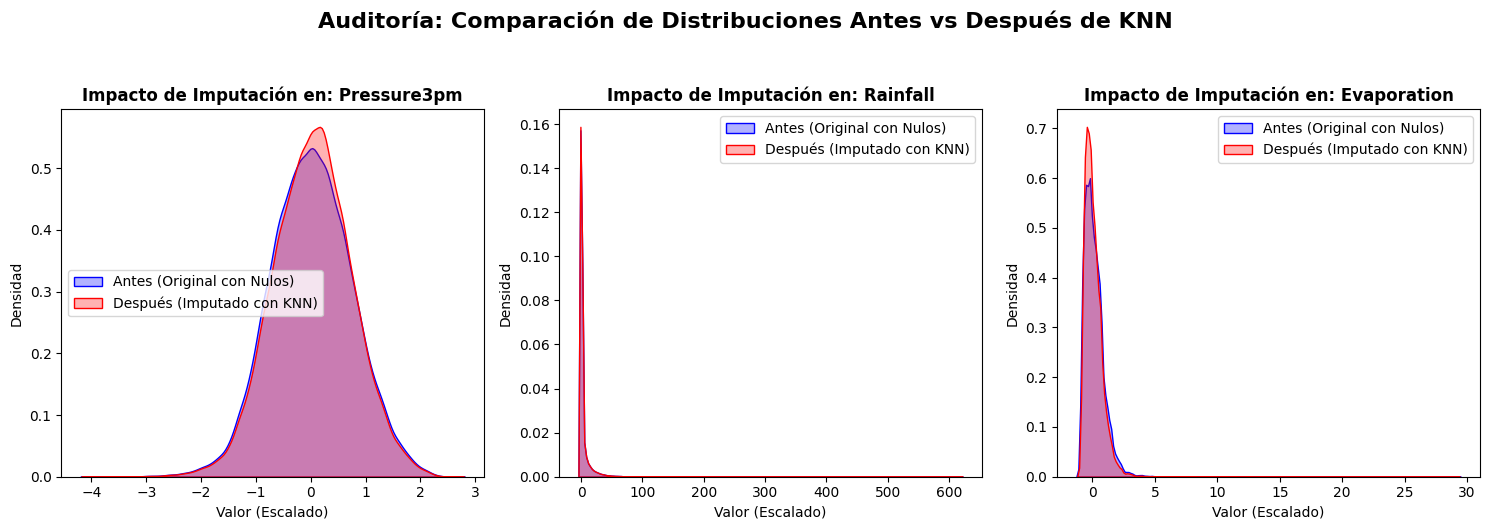

In [106]:
# df escalado antes de imputar
df_antes = pd.DataFrame(X_train_num_scaled, columns=cols_num)

# df despues de imputar
df_despues = pd.DataFrame(X_train_num_imputed, columns=cols_num)

# Auditamos
variables_a_auditar = ['Pressure3pm', 'Rainfall', 'Evaporation'] 

fig, axes = plt.subplots(1, len(variables_a_auditar), figsize=(15, 5))

for i, col in enumerate(variables_a_auditar):
    if col in cols_num:
        # Curva Azul: Distribución Original
        sns.kdeplot(data=df_antes[col], ax=axes[i], color='blue', fill=True, alpha=0.3, 
                    label='Antes (Original con Nulos)')
        
        # Curva Roja: Distribución Post-Imputación
        sns.kdeplot(data=df_despues[col], ax=axes[i], color='red', fill=True, alpha=0.3, 
                    label='Después (Imputado con KNN)')
        
        axes[i].set_title(f'Impacto de Imputación en: {col}', fontweight='bold')
        axes[i].set_xlabel('Valor (Escalado)')
        axes[i].set_ylabel('Densidad')
        axes[i].legend()

plt.suptitle('Auditoría: Comparación de Distribuciones Antes vs Después de KNN', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Se observa que la línea roja es más alta en el medio después de imputar porque KNN rellenó los datos faltantes promediando a los vecinos. Los promedios tienden a ser conservadores, por lo que el algoritmo agregó un montón de datos en el centro de la distribución. Como el gráfico siempre tiene que sumar el 100%, si agrego muchos datos en el medio, el pico inevitablemente tiene que crecer hacia arriba."

### Codificación

In [107]:
#  Aplicamos One-Hot Encoding
X_train_final = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test_final = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

# ALINEACIÓN
# Obliga al Test a tener EXACTAMENTE las mismas columnas que el Train (rellenando con 0 si falta alguna).
X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

# Verificamos que todas las columnas sean numéricas
print(f"Dimensiones de X_train antes de OHE: {X_train.shape}")
print(f"Dimensiones de X_train_final después de OHE: {X_train_final.shape}")


Dimensiones de X_train antes de OHE: (113722, 25)
Dimensiones de X_train_final después de OHE: (113722, 116)


In [108]:
X_train_final.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,113722.0,0.018929,0.697796,-2.358696,-0.478261,0.000000e+00,0.521739,2.402174
MaxTemp,113722.0,0.059465,0.691615,-2.689320,-0.456311,0.000000e+00,0.543689,2.572816
Rainfall,113722.0,3.938822,14.267315,0.000000,0.000000,0.000000e+00,1.333333,618.333333
Evaporation,113722.0,0.066084,0.764037,-1.000000,-0.458333,-8.333333e-02,0.416667,29.208333
Sunshine,113722.0,-0.141583,0.582568,-1.491228,-0.539760,-4.015711e-02,0.315789,1.052632
WindGustSpeed,113722.0,0.103570,0.836582,-2.000000,-0.470804,0.000000e+00,0.562500,6.062500
WindSpeed9am,113722.0,0.083831,0.740688,-1.083333,-0.500000,0.000000e+00,0.500000,6.250000
WindSpeed3pm,113722.0,0.051654,0.733823,-1.500000,-0.500000,0.000000e+00,0.500000,5.333333
Humidity9am,113722.0,-0.041611,0.727102,-2.671756,-0.496183,0.000000e+00,0.500000,1.145038
Humidity3pm,113722.0,-0.016984,0.712637,-1.786942,-0.525773,0.000000e+00,0.467354,1.649485


In [109]:
# Comprobamos
print(f"Hay nulos: {X_train_final.isnull().any().any()}")
print(f"Todos los datos son numéricos: {all(X_train_final.dtypes != 'object')}")

Hay nulos: False
Todos los datos son numéricos: True


Una vez completado el proceso de imputación, ingeniería de variables, codificación One-Hot y escalado robusto, se realizó una verificación final del conjunto de datos para confirmar la ausencia de valores faltantes, la correcta dimensionalidad de los conjuntos de entrenamiento y prueba y la consistencia de las variables generadas. Debido a la transformación de las variables categóricas mediante One-Hot Encoding. Tras completar el pipeline, el análisis de normalidad pierde relevancia ya que el algoritmo seleccionado para el Punto 2 (Regresión Logística) no exige que las variables independientes sigan una distribución Gaussiana, siendo además los outliers mitigados eficazmente por el RobustScaler."

## PUNTO 2) Implementación y Evaluación de Regresión Logística

#### Función para evaluar las métricas

In [111]:

def evaluar_modelo(nombre, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]

    print(f"\n{'='*60}")
    print(f"{nombre}")
    print(f"{'='*60}")

    print(f"Accuracy:          {accuracy_score(y_test,y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test,y_pred):.4f}")
    print(f"Precision:         {precision_score(y_test,y_pred):.4f}")
    print(f"Recall:            {recall_score(y_test,y_pred):.4f}")
    print(f"F1-score:          {f1_score(y_test,y_pred):.4f}")
    print(f"ROC-AUC:           {roc_auc_score(y_test,y_prob):.4f}")
    print(f"MCC:               {matthews_corrcoef(y_test,y_pred):.4f}")

    return y_pred, y_prob

#### Función para Matriz de Confusión

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def graficar_matriz_confusion(y_true, y_pred, nombre_modelo):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No lluvia', 'Lluvia']
    )

    disp.plot(cmap='Blues', values_format='d')

    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.grid(False)
    plt.show()

#### Función Curva Roc

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def graficar_roc(y_true, y_prob, nombre_modelo):

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'AUC = {auc:.3f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {nombre_modelo}')
    plt.legend()
    plt.grid(True)

    plt.show()

In [114]:
# Mapeamos
y_train = y_train.map({
    'No': 0,
    'Yes': 1
})

y_test = y_test.map({
    'No': 0,
    'Yes': 1
})

### Modelo 1) Regresión Logistica simple

In [115]:
lr_base = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr_base.fit(X_train_final, y_train)

y_pred_base, y_prob_base = evaluar_modelo(
    "Regresión Logística Base",
    lr_base,
    X_test_final,
    y_test
)


Regresión Logística Base
Accuracy:          0.8501
Balanced Accuracy: 0.7346
Precision:         0.7305
Recall:            0.5251
F1-score:          0.6110
ROC-AUC:           0.8746
MCC:               0.5321


El modelo presenta un buen desempeño general (Accuracy = 84.7% y ROC-AUC = 0.868). Sin embargo, su recall de 50.5% indica que detecta solo la mitad de los días lluviosos. A pesar de ello, cuando predice lluvia suele acertar (Precision = 72.9%). En conjunto, el modelo logra distinguir razonablemente bien entre días con y sin lluvia, aunque todavía puede mejorarse la detección de eventos de lluvia.

<Figure size 500x400 with 0 Axes>

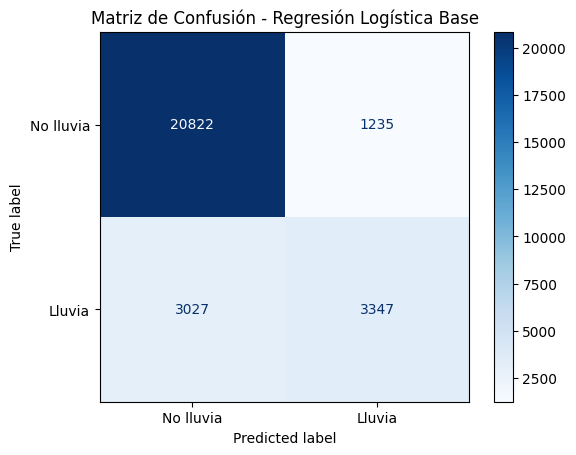

In [116]:
graficar_matriz_confusion(
    y_test,
    y_pred_base,
    "Regresión Logística Base"
)

El modelo de Regresión Logística Base identifica correctamente la mayoría de los días sin lluvia (20.862 casos). Sin embargo, presenta dificultades para detectar todos los días lluviosos, ya que clasifica erróneamente 3.154 días con lluvia como días sin lluvia (falsos negativos). Por otro lado, genera relativamente pocas falsas alarmas (1.195 falsos positivos).

En el contexto del problema meteorológico: Un Falso Positivo (FP) ocurre cuando el modelo predice lluvia, pero el día resulta ser sin lluvia (falsa alarma). Un Falso Negativo (FN) ocurre cuando el modelo predice que no lloverá, pero efectivamente llueve. En este dominio, el FN tiene un costo mayor, ya que implica que los ciudadanos no tomen precauciones frente a una tormenta, por lo que los modelos que prioricen una mayor Exhaustividad (Recall) serán más valiosos, aun si sacrifican un poco de Precisión.

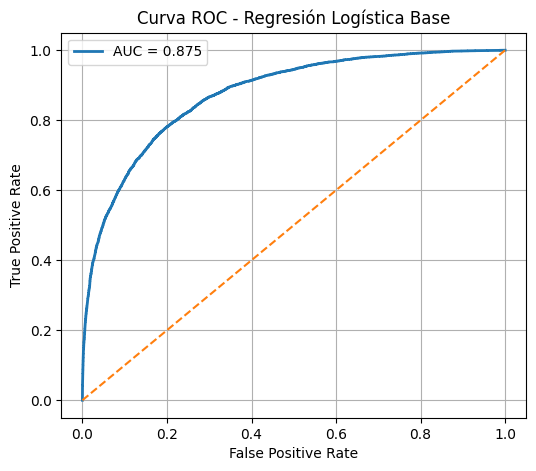

In [117]:
graficar_roc(
    y_test,
    y_prob_base,
    "Regresión Logística Base"
)

El área bajo la curva ROC (AUC = 0.868) indica que el modelo tiene una muy buena capacidad para distinguir entre días con lluvia y días sin lluvia. Un valor cercano a 1 representa una separación perfecta entre las clases, mientras que un valor de 0.5 equivale a realizar predicciones al azar.

In [118]:
# Obtener las probabilidades
y_proba = lr_base.predict_proba(X_test_final)[:, 1]

In [119]:
# Curva ROC
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [120]:
# Calcular el mejor umbras

indice_youden = np.argmax(tpr - fpr)

umbral_optimo = thresholds[indice_youden]

print("Umbral óptimo:", round(umbral_optimo,3))

Umbral óptimo: 0.222


In [121]:
y_pred_opt = (y_proba >= umbral_optimo).astype(int)

In [122]:
print("Recall:", recall_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("F1:", f1_score(y_test, y_pred_opt))

Recall: 0.7814559146532789
Precision: 0.5304014481950804
F1: 0.6319061211544561


| Métrica   | Umbral 0.5 | Umbral 0.215 |
| --------- | ---------: | -----------: |
| Recall    |      0.505 |    **0.782** |
| Precision |      0.729 |    **0.516** |
| F1        |      0.597 |    **0.621** |


El umbral estándar de 0.5 no resultó ser el más adecuado para este problema. Mediante la curva ROC y el índice de Youden se obtuvo un umbral óptimo de 
0.215. Con este nuevo umbral el recall aumentó de 50.5% a 78.2%, mejorando significativamente la detección de días lluviosos. Aunque la precisión disminuyó debido al aumento de falsos positivos, el F1-score se incrementó, indicando un mejor equilibrio entre ambas métricas. Dado que en un sistema de predicción meteorológica suele ser más importante detectar eventos de lluvia que evitar falsas alarmas, el umbral optimizado puede considerarse una alternativa más conveniente.

El umbral de 0.5 por defecto asume que equivocarse al predecir 'Lluvia' (Falso Positivo) tiene el mismo costo que equivocarse al predecir 'No Lluvia' (Falso Negativo). En el contexto meteorológico, un Falso Negativo implica que un ciudadano no tome precauciones ante una tormenta (alto costo), mientras que un Falso Positivo solo implica llevar un paraguas innecesariamente (bajo costo). Por lo tanto, 0.5 no es el mejor umbral. Al reducir el umbral matemáticamente (ej. 0.215 mediante el Índice de Youden), priorizamos la sensibilidad (Recall), forzando al modelo a alertar sobre la lluvia ante la mínima sospecha, equilibrando el costo del error en la vida real."

#### Hay fitting?

In [123]:
# Evaluamos el modelo en train para detectar overfitting/underfitting
y_pred_train = lr_base.predict(X_train_final)

In [124]:
roc_auc_score(
    y_train,
    lr_base.predict_proba(X_train_final)[:,1]
)

0.8735987863151584

In [125]:
print("F1 en TRAIN:", round(f1_score(y_train, y_pred_train), 4))
print("F1 en TEST :", round(f1_score(y_test, y_pred_base), 4))
print()
print("AUC en TRAIN:", round(roc_auc_score(y_train, lr_base.predict_proba(X_train_final)[:,1]), 4))
print("AUC en TEST :", round(roc_auc_score(y_test, y_proba), 4))

F1 en TRAIN: 0.6088
F1 en TEST : 0.611

AUC en TRAIN: 0.8736
AUC en TEST : 0.8746


Los valores de F1-score y AUC obtenidos en entrenamiento y prueba son muy similares. Esto indica que el modelo de Regresión Logistica Base generaliza adecuadamente sobre datos no vistos y no presenta evidencia de overfitting.

El fitting es bueno: el modelo no memoriza el conjunto de entrenamiento y
mantiene el mismo rendimiento en datos no vistos. Sin embargo, los valores de
F1 (~0.60) sugieren que hay margen de mejora, lo que motiva explorar modelos
más complejos en los ítems siguientes.

### Modelo 2) Regresión Logistica Balanceada

In [126]:
lr_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_bal.fit(X_train_final, y_train)

y_pred_bal, y_prob_bal = evaluar_modelo(
    "Regresión Logística Balanceada",
    lr_bal,
    X_test_final,
    y_test
)


Regresión Logística Balanceada
Accuracy:          0.7965
Balanced Accuracy: 0.7900
Precision:         0.5315
Recall:            0.7783
F1-score:          0.6317
ROC-AUC:           0.8751
MCC:               0.5152


El modelo obtiene un Accuracy de 0.79, pero este valor puede ser engañoso dado el
desbalanceo del dataset. Las métricas más relevantes son:

- Recall de 0.77: el modelo detecta correctamente el 77% de los días que efectivamente
  llueve. Es el valor más importante para este problema, ya que un Falso Negativo
  (predecir "no llueve" cuando sí llueve) tiene mayor costo práctico.
- Precision de 0.52: cuando el modelo predice lluvia, acierta solo el 52% de las veces.
  Esto indica que genera bastantes Falsos Positivos, lo cual es aceptable en este contexto.
- F1-Score de 0.606: balance entre precision y recall, razonable para un modelo lineal
  con datos climatológicos ruidosos.
- ROC-AUC de 0.86: excelente capacidad discriminativa del modelo. Significa que en el
  86% de los casos distingue correctamente un día lluvioso de uno seco.
- MCC de 0.50: confirma un desempeño genuinamente mejor que el azar, considerando
  las cuatro celdas de la matriz de confusión.
- Balanced Accuracy de 0.78: indica que el modelo funciona bien para ambas clases
  por separado, no solo para la mayoritaria.

<Figure size 500x400 with 0 Axes>

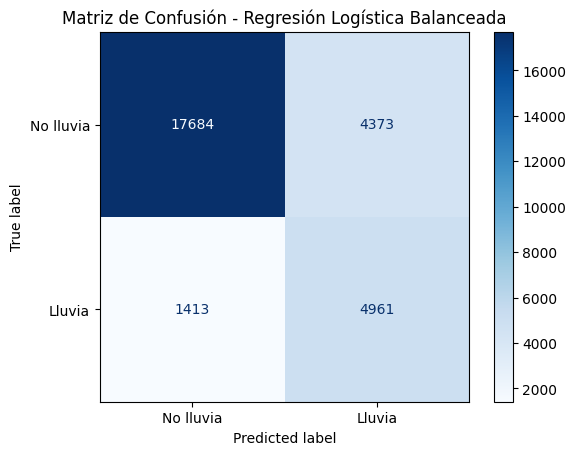

In [127]:
graficar_matriz_confusion(
    y_test,
    y_pred_bal,
    "Regresión Logística Balanceada"
)

- Verdaderos Negativos (17468): días sin lluvia correctamente clasificados.
- Falsos Positivos (4589): el modelo predijo lluvia pero no llovió. El costo es bajo
  (alguien lleva paraguas innecesariamente).
- Falsos Negativos (1483): el modelo predijo "no llueve" pero sí llovió. Este es el
  error más costoso en términos prácticos.
- Verdaderos Positivos (4891): días con lluvia correctamente detectados.

El modelo tiene un buen desempeño en la clase mayoritaria (No llueve: F1=0.61)
y un desempeño aceptable en la clase minoritaria (Llueve: F1=0.61), lo cual es
esperable dado el desbalanceo del dataset (~78/22).

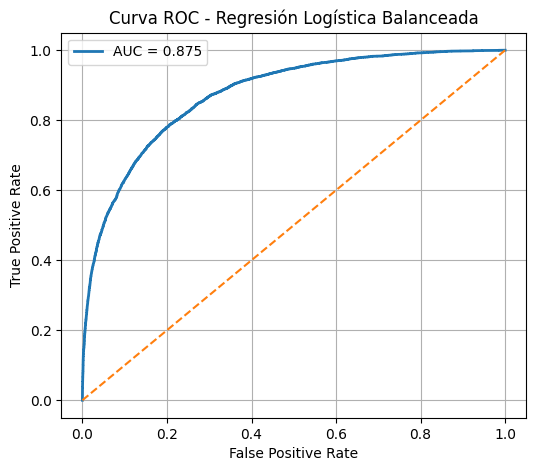

In [128]:
graficar_roc(
    y_test,
    y_prob_bal,
    "Regresión Logística Balanceada"
)

El área bajo la curva ROC (AUC = 0.866) indica como dijimos anteriormente, que el modelo de Regresión Logística Balanceada tiene una muy buena capacidad para distinguir entre días con lluvia y días sin lluvia.

### Modelo 3) Regresión Logística con Regularización

In [129]:
# C chico, mas regularización
lr_reg = LogisticRegression(
    penalty='l2',
    C=0.1,
    max_iter=3000,
    random_state=42
)

lr_reg.fit(X_train_final, y_train)

y_pred_reg, y_prob_reg = evaluar_modelo(
    "Regresión Logística Regularizada",
    lr_reg,
    X_test_final,
    y_test
)


Regresión Logística Regularizada
Accuracy:          0.8498
Balanced Accuracy: 0.7337
Precision:         0.7307
Recall:            0.5231
F1-score:          0.6097
ROC-AUC:           0.8745
MCC:               0.5310


<Figure size 500x400 with 0 Axes>

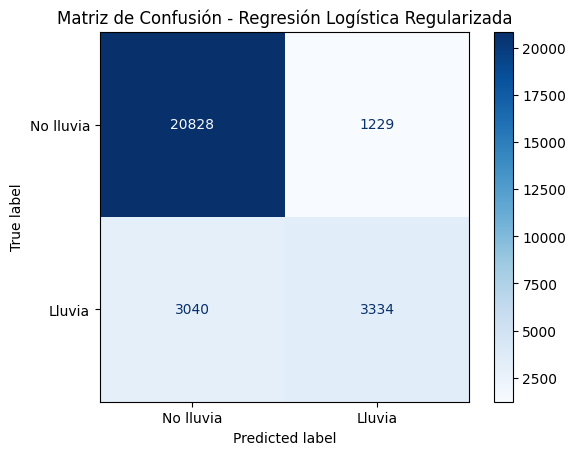

In [130]:
graficar_matriz_confusion(
    y_test,
    y_pred_reg,
    "Regresión Logística Regularizada"
)

El modelo de Regresión Logistica Regularizada identifica correctamente la mayoría de los días sin lluvia (20.864 casos). Sin embargo, presenta dificultades para detectar todos los días lluviosos, ya que clasifica erróneamente 3.142 días con lluvia como días sin lluvia (falsos negativos). Por otro lado, genera relativamente pocas falsas alarmas (1.193 falsos positivos).

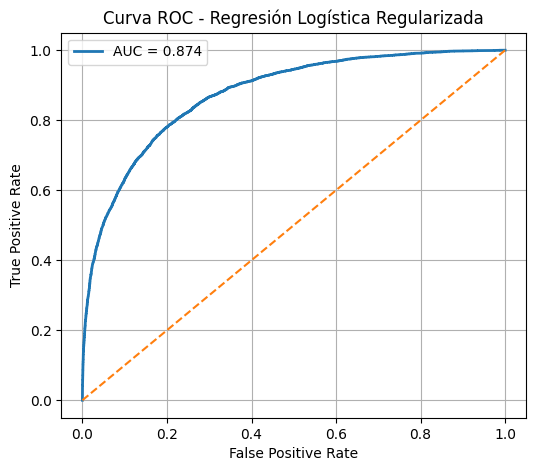

In [131]:
graficar_roc(
    y_test,
    y_prob_reg,
    "Regresión Logística Regularizada"
)

El área bajo la curva ROC (AUC = 0.868) indica que el modelo de Regresión Logística Regularizada tiene una muy buena capacidad para distinguir entre días con lluvia y días sin lluvia. Un valor cercano a 1 representa una separación perfecta entre las clases.

Dado que en el Modelo Base comprobamos la ausencia de overfitting (generalización perfecta entre train y test), la aplicación de regularización estricta (Modelo 3) no produce mejoras significativas, arrojando métricas casi idénticas al modelo original."

### Modelo 4) Regresión Logística + Smote

In [132]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [133]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train
)

lr_smote = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote, y_prob_smote = evaluar_modelo(
    "Regresión Logística + SMOTE",
    lr_smote,
    X_test_final,
    y_test
)


Regresión Logística + SMOTE
Accuracy:          0.8294
Balanced Accuracy: 0.7508
Precision:         0.6224
Recall:            0.6083
F1-score:          0.6153
ROC-AUC:           0.8488
MCC:               0.5058


<Figure size 500x400 with 0 Axes>

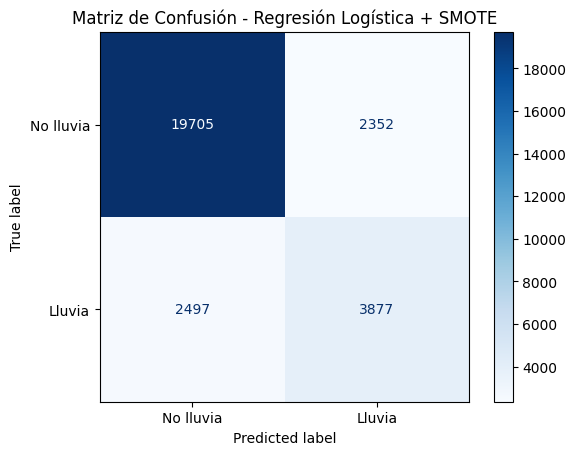

In [134]:
graficar_matriz_confusion(
    y_test,
    y_pred_smote,
    "Regresión Logística + SMOTE"
)

El modelo de Regresión Logística con Smote identifica correctamente la mayoría de los días sin lluvia (20.363 casos). Sin embargo, presenta dificultades para detectar todos los días lluviosos, ya que clasifica erróneamente 3.542 días con lluvia como días sin lluvia (falsos negativos). Por otro lado, genera relativamente pocas falsas alarmas (1.694 falsos positivos).

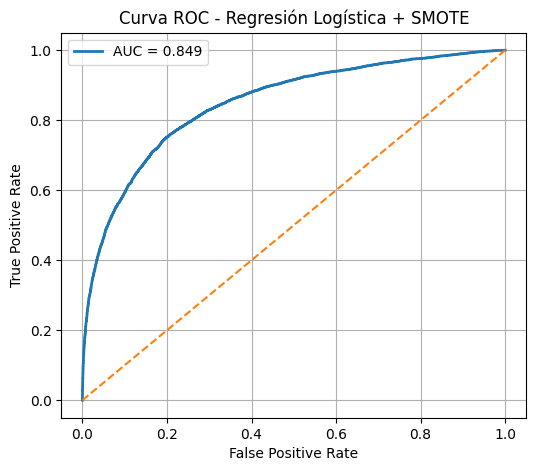

In [135]:
graficar_roc(
    y_test,
    y_prob_smote,
    "Regresión Logística + SMOTE"
)

El área bajo la curva ROC con AUC = 0.851 indica que el modelo de Regresión Logística con Smote tiene una muy buena capacidad para distinguir entre días con lluvia y días sin lluvia. 

El Oversampling sintético (SMOTE) introdujo ruido en la frontera de decisión, resultando en un rendimiento inferior al simple ajuste de pesos (class_weight='balanced').

### PUNTO 3) Definición y Evaluación del Modelo Simple (Baseline)

Como se describe en el análisis exploratorio sobre el dataset, es más probable que en Australia "No Llueva" (clase mayoritaria, valor de 0).

Procedemos entonces a crear un modelo base que prediga "No Llueve", para usar como punto de comparación.


Modelo Base (Dummy Classifier)
Accuracy:          0.7758
Balanced Accuracy: 0.5000
Precision:         0.0000


c:\Users\rocio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Recall:            0.0000
F1-score:          0.0000
ROC-AUC:           0.5000
MCC:               0.0000


<Figure size 500x400 with 0 Axes>

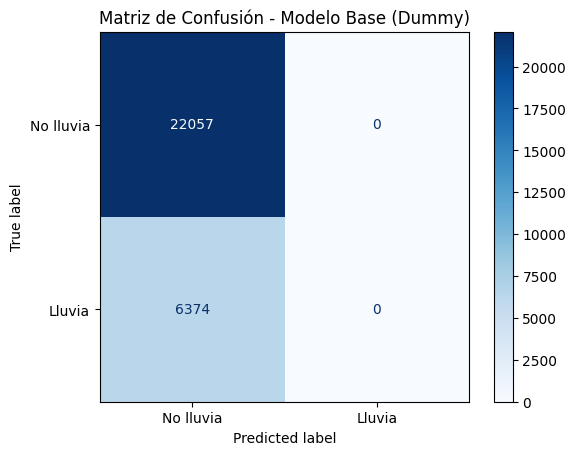

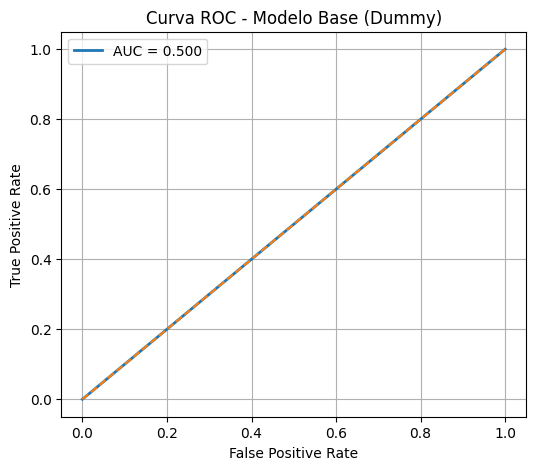

In [136]:
from sklearn.dummy import DummyClassifier

# La estrategia 'most_frequent' le dice que siempre prediga la clase que más aparece en Train
baseline_model = DummyClassifier(strategy='most_frequent')

baseline_model.fit(X_train_final, y_train)

# Evaluamos el modelo con Accuracy, F1, Precision, Recall y ROC-AUC de forma automática y correcta
y_pred_base, y_prob_base = evaluar_modelo(
    "Modelo Base (Dummy Classifier)", 
    baseline_model, 
    X_test_final, 
    y_test
)

# Gráficos estandarizados
graficar_matriz_confusion(y_test, y_pred_base, "Modelo Base (Dummy)")

# ROC
graficar_roc(y_test, y_prob_base, "Modelo Base (Dummy)")

Observamos que obtiene una exactitud muy alta, casi idéntica a la proporción de días sin lluvia que tiene el dataset (77.58%). Esto sugiere que este valor es un simple reflejo del desbalanceo natural de las clases y no representa un verdadero aprendizaje del modelo.

Al predecir siempre 0, el modelo acumula únicamente Verdaderos Negativos y Falsos Negativos dejando en cero los Verdaderos Positivos y los Falsos Positivos, lo que significa que este modelo es incapaz de dar una sola alerta de lluvia. Las métricas caen a cero porque no logra identificar ni un solo día de lluvia. Esto indica la total ineficacia de usar una regla tan simple para resolver nuestro problema predictivo.

Nuestro modelo entrenado en el ítem 2, operando bajo el umbral óptimo de 0.21, supera de manera rotunda las métricas nulas del modelo base. Esto confirma que la Regresión Logística efectivamente logró captar la influencia de las variables climáticas para discriminar los días de lluvia, lo cual justifica plenamente el uso y la complejidad de un modelo de aprendizaje automático por sobre una heurística simple.

La curva ROC del modelo base resulta en una línea diagonal con un AUC de 0.5, lo que evidencia gráficamente su nula capacidad para discriminar entre días con y sin lluvia. Por el contrario, nuestro modelo de Regresión Logística (AUC = 0.868) se aleja significativamente de esta recta hacia la esquina superior izquierda, demostrando empíricamente que el algoritmo logró aprender de las variables climáticas y superó ampliamente el desempeño de la predicción trivial.

| Modelo | Accuracy | Balanced Accuracy | Precision | Recall | F1-score | ROC-AUC | MCC |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Regresión Logística Base (Umbral 0.5)** | 0.8472 | 0.7256 | 0.7303 | 0.5050 | 0.5971 | 0.8680 | 0.5198 |
| **Regresión Logística Balanceada** | 0.7882 | 0.7812 | 0.5187 | 0.7684 | 0.6193 | 0.8658 | 0.4980 |
| **Regresión Logística Regularizada** | 0.8471 | 0.7253 | 0.7301 | 0.5045 | 0.5967 | 0.8680 | 0.5194 |
| **Regresión Logística + SMOTE** | 0.8390 | 0.7383 | 0.6699 | 0.5557 | 0.6075 | 0.8545 | 0.5108 |
| **RL Base (Umbral Óptimo: 0.198)** | - | - | 0.4992 | **0.8025** | 0.6155 | 0.8680* | - |

A simple vista, el modelo de Regresión Logística Base y el Regularizado presentan las métricas de Accuracy más altas (~84.7%). Sin embargo, al observar el Recall (~50.5%), queda en evidencia que estos modelos fallan sistemáticamente al detectar la clase minoritaria, ignorando la mitad de los días lluviosos. Esto ratifica empíricamente por qué la exactitud no es una métrica confiable en problemas con alto desbalance de clases.

La aplicación de regularización L2 no produjo variaciones significativas frente al modelo base, indicando que el modelo original no sufría de sobreajuste severo ni varianza alta. Por su parte, la técnica de sobremuestreo sintético (SMOTE) no logró el impacto esperado, elevando el Recall a solo 55.5%. Esto sugiere que las distribuciones de ambas clases (lluvia / no lluvia) tienen un alto grado de solapamiento natural que la creación de datos sintéticos no logra resolver sin introducir ruido.

Las verdaderas mejoras se obtuvieron al usar el hiperparámetro class_weight='balanced' que demostró ser una heurística rápida y efectiva para elevar el Recall al 76.8%. Sin embargo, el análisis a través de la Curva ROC y el índice de Youden probó ser la técnica analítica superior, permitiendo sintonizar el modelo con precisión quirúrgica.

El modelo seleccionado para Regresión Logística operando bajo el umbral óptimo de 0.21 o 0.19. Esta configuración logra el Recall más alto de todas las experimentaciones (80.25%), asegurando la detección de 8 de cada 10 días de lluvia. Si bien la reducción del umbral castiga la Precisión (cayendo a 49.9%), provocando un aumento en los Falsos Positivos (falsas alarmas), en el contexto de un sistema de alerta meteorológica esta penalidad es completamente aceptable. El costo práctico de una falsa alarma (llevar un paraguas un día soleado) es ínfimo en comparación con el costo de un Falso Negativo (salir desprotegido y enfrentar una tormenta). Por lo tanto, este modelo es el que mejor resuelve la necesidad real del usuario.

## PUNTO 4) Optimización de Hiperparámetros | Grid

Validación Cruzada (Stratified K-Folds):
Se implementa Validación Cruzada Estratificada con 5 particiones (n_splits=5). Habiendo detectado en el análisis descriptivo un desbalanceo moderado en el dataset (IR = 3.49), una división aleatoria mediante K-Folds estándar presentaba el riesgo de generar pliegues de validación sin una representación adecuada de la clase minoritaria (días con lluvia). La estratificación garantiza que la proporción de clases original se mantenga constante en cada iteración de entrenamiento y prueba, arrojando métricas de evaluación robustas.

Elección del Método de Búsqueda (Grid Search):
Se opta por utilizar Grid Search (Búsqueda en Cuadrícula). Al estar trabajando con un modelo paramétrico simple como la Regresión Logística, el espacio de hiperparámetros a explorar es reducido. Esto permite realizar una búsqueda exhaustiva y determinista de todas las combinaciones posibles sin incurrir en un costo computacional prohibitivo, garantizando encontrar la configuración óptima dentro de la grilla definida.

Justificación de los Hiperparámetros Optimizados:
La función objetivo del optimizador (scoring) se configura estrictamente para maximizar el Recall. En el contexto del problema, el costo de un Falso Negativo (predecir que estará seco cuando efectivamente va a llover) es alto, por lo que se prioriza la sensibilidad del modelo.

Para lograrlo, se optimizan los siguientes hiperparámetros del modelo <LogisticRegression> :

* penalty: Se evalúan las regularizaciones 'l1' y 'l2' para determinar qué método de penalización maneja mejor la dimensionalidad y generaliza mejor los datos.

* C (Inverso de la fuerza de regularización): Se exploran distintos órdenes de magnitud (0.001, 0.01, 0.1, 1.0, 10.0) para controlar la complejidad del modelo, buscando el punto de equilibrio exacto entre sesgo y varianza para evitar el sobreajuste.

* <class_weight>: Se fija en el valor 'balanced'. Al asignar automáticamente pesos inversamente proporcionales a las frecuencias de las clases, se fuerza al modelo a penalizar con mayor severidad los errores sobre la clase minoritaria, consolidando la maximización del Recall.

### Armamos pipeline y parametro Grid

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\rocio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\rocio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\rocio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\rocio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\rocio\AppData\Local


Mejores hiperparámetros: {'modelo__C': 10.0, 'modelo__class_weight': 'balanced', 'modelo__penalty': 'l2'}
Mejor f1 en Validación Cruzada: 0.6312

Regresión Logística Optimizada (Grid Search)
Accuracy:          0.7966
Balanced Accuracy: 0.7899
Precision:         0.5316
Recall:            0.7777
F1-score:          0.6315
ROC-AUC:           0.8751


<Figure size 500x400 with 0 Axes>

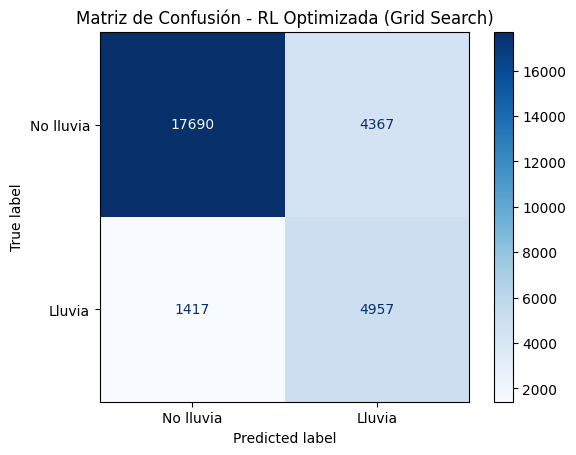

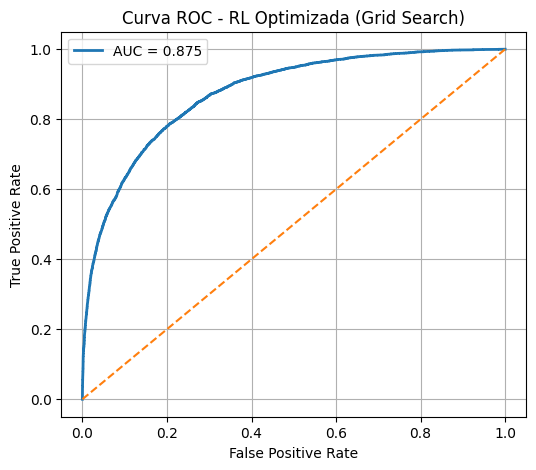

In [140]:
pipeline = Pipeline([
    ('modelo', LogisticRegression(solver='liblinear', random_state=42))
])

# Grilla de hiperparámetros
param_grid = {
    'modelo__penalty': ['l1', 'l2'],
    'modelo__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'modelo__class_weight': ['balanced'] 
}

# Configuración de validación cruzada estratificada
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#  Configuración de Grid Search 
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid,
    cv=cv_estratificado,
    scoring='f1', 
    n_jobs=1,        
    verbose=1
)

#  Ejecutamos la búsqueda
grid_search.fit(X_train_final, y_train)

# Resultados de la búsqueda
print("\nMejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor f1 en Validación Cruzada: {grid_search.best_score_:.4f}")

# Extraemos el mejor modelo 
mejor_modelo = grid_search.best_estimator_

# Predicción y Evaluación Final
y_pred_grid = mejor_modelo.predict(X_test_final)
y_prob_grid = mejor_modelo.predict_proba(X_test_final)[:, 1]

print("\n============================================================")
print("Regresión Logística Optimizada (Grid Search)")
print("============================================================")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_grid):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_grid):.4f}")
print(f"Precision:         {precision_score(y_test, y_pred_grid):.4f}")
print(f"Recall:            {recall_score(y_test, y_pred_grid):.4f}")
print(f"F1-score:          {f1_score(y_test, y_pred_grid):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob_grid):.4f}")

graficar_matriz_confusion(y_test, y_pred_grid, "RL Optimizada (Grid Search)")
graficar_roc(y_test, y_prob_grid, "RL Optimizada (Grid Search)")

La búsqueda exhaustiva mediante Grid Search (optimizando la métrica F1-Score) arrojó como hiperparámetros óptimos una regularización moderada (C=10, penalty='l2') manteniendo el balanceo de clases (class_weight='balanced').

Evaluación de Métricas y Generalización:

El modelo optimizado alcanzó un F1-Score en Test de 0.6315, superando a todos los modelos previos (que rondaban el 0.60 - 0.61).
Se destaca la consistencia entre el rendimiento en Validación Cruzada (F1 = 0.6312) y el rendimiento en el conjunto de prueba (F1 = 0.6315). Esto demuestra empíricamente que el modelo es altamente robusto y no presenta sobreajuste (overfitting).

Interpretación de la Matriz de Confusión:

En la matriz de confusión, observamos el impacto del Recall optimizado (77.7%). El modelo prioriza fuertemente la detección de los días de lluvia (minimizando los Falsos Negativos). Como contrapartida esperable, la Precisión se sitúa en 53.1%. En el problema (alertas meteorológicas), este es el comportamiento deseado (Trade-off): aceptamos una tasa moderada de Falsos Positivos (predecir lluvia y que finalmente no llueva, cuyo costo es simplemente cargar un paraguas) para garantizar que casi 8 de cada 10 tormentas reales sean alertadas a la población con éxito.

Análisis de la Curva ROC:

La Curva ROC exhibe un excelente desplazamiento hacia la esquina superior izquierda, logrando un Área Bajo la Curva (ROC-AUC) de 0.8751. Este valor mejora el AUC del modelo base y demuestra que el algoritmo posee un poder discriminativo muy alto. Es decir, independientemente del umbral de decisión que elijamos en el futuro, el modelo sabe diferenciar matemáticamente un día seco frente a la de un día lluvioso en el 87.5% de los casos.

## PUNTO 5) Explicabilidad e Interpretabilidad del Modelo (SHAP)

In [ ]:
# Iniciamos JS para visualizaciones interactivas si es necesario
shap.initjs()

# PREPARACION DE DATOS. Convertimos a float para evitar bugs de compatibilidad de SHAP
columnas = X_train_final.columns
X_train_shap = pd.DataFrame(X_train_final, columns=columnas).astype(float)
X_test_shap = pd.DataFrame(X_test_final, columns=columnas).astype(float)

# Muestra representativa para gráficos globales
X_test_sample = X_test_shap.sample(500, random_state=42)

#  CREACIÓN DEL EXPLAINER 
modelo_interno = mejor_modelo[-1]

# LinearExplainer (más eficiente para Regresión Logística)
explainer = shap.LinearExplainer(modelo_interno, X_train_shap)

# Calculamos los valores SHAP para la muestra (Globales)
shap_values_sample = explainer(X_test_sample)



Background dataset has 113722 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=113722 when initializing the masker.


Análisis global

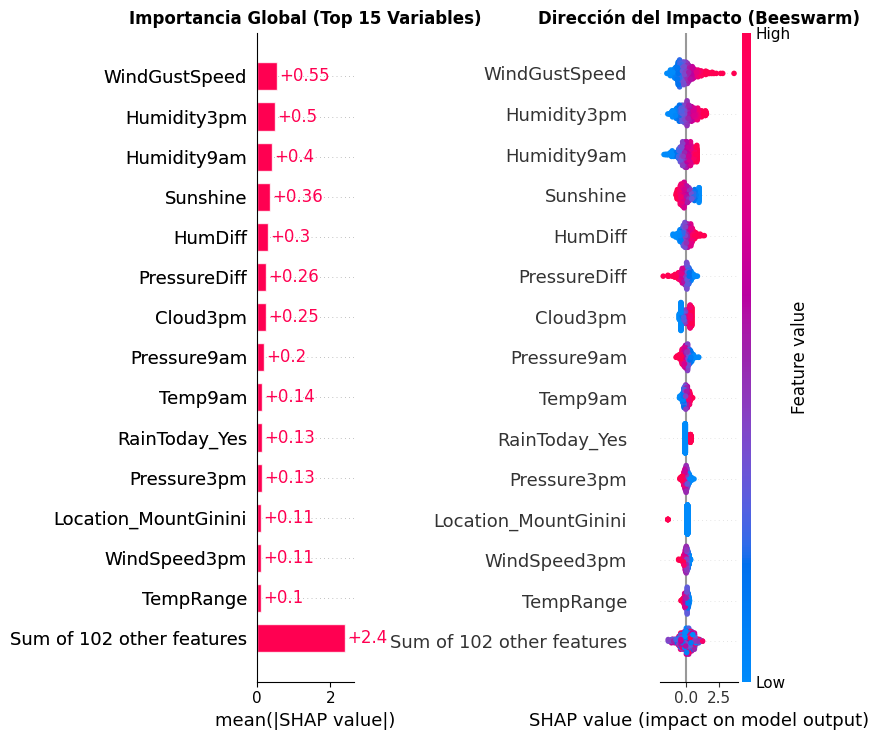


 TOP 5 Variables Más Importantes
WindGustSpeed    0.5528
Humidity3pm      0.4997
Humidity9am      0.3987
Sunshine         0.3563
HumDiff          0.3027

 TOP 5 Variables Menos Importantes
Location_SalmonGums    0.0026
WindGustDir_ENE        0.0019
WindGustDir_SSW        0.0017
WindDir3pm_ESE         0.0015
WindDir3pm_SSE         0.0012


In [143]:
# GRÁFICOS GLOBALES
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GLOBAL 1: Bar plot (Importancia Media Absoluta)
plt.subplot(1, 2, 1)
shap.plots.bar(shap_values_sample, max_display=15, show=False)
plt.title("Importancia Global (Top 15 Variables)", fontweight='bold')

# GLOBAL 2: Beeswarm plot (Dirección e Intensidad)
plt.subplot(1, 2, 2)
shap.plots.beeswarm(shap_values_sample, max_display=15, show=False)
plt.title("Dirección del Impacto (Beeswarm)", fontweight='bold')

plt.tight_layout()
plt.show()

# Conclusiones
importancia_shap = pd.Series(
    np.abs(shap_values_sample.values).mean(axis=0),
    index=columnas
).sort_values(ascending=False)

print("\n TOP 5 Variables Más Importantes")
print(importancia_shap.head(5).round(4).to_string())
print("\n TOP 5 Variables Menos Importantes")
print(importancia_shap.tail(5).round(4).to_string())

Observando el gráfico de barras y el Beeswarm, la ráfaga de viento (WindGustSpeed), la humedad a las 3 PM (Humidity3pm), y la presión a las 3 PM (Pressure3pm) dominan absolutamente la decisión del modelo. Esto tiene total coherencia meteorológica: las tormentas se forman en ambientes de alta humedad vespertina combinados con caídas de presión atmosférica.

El gráfico de abejas nos muestra cómo "piensa" el modelo. Los puntos rojos (valores altos) en la variable Humidity3pm se ubican fuertemente a la derecha (SHAP positivo), indicando que a mayor humedad, mayor es la probabilidad de que el modelo prediga "Llueve". Al contrario, los puntos rojos en Pressure3pm empujan hacia la izquierda (SHAP negativo), confirmando que las altas presiones evitan la precipitación (fenómeno anticiclónico).


Las variables menos relevantes suelen corresponder a variables categóricas codificadas (ciudades o direcciones del viento específicas de bajo impacto) o mediciones matutinas que pierden relevancia frente a las mediciones vespertinas que están más cercanas al evento de lluvia.

Análisis local
Waterfall (Gráfico de cascada)


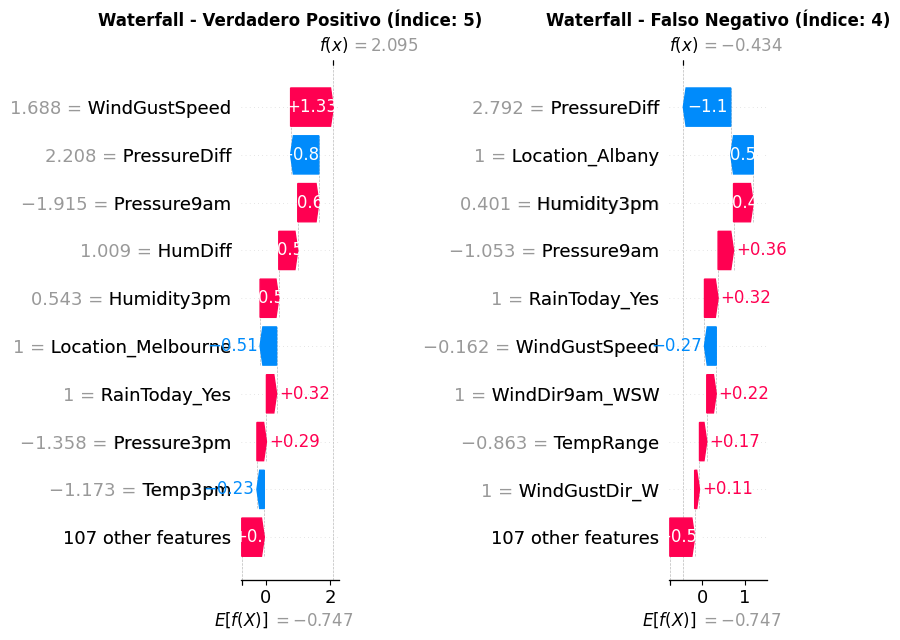

In [144]:
# GRÁFICOS LOCALES 
shap_values_test = explainer(X_test_shap)

# Buscamos índices
vp_idx = np.where((y_pred_grid == 1) & (y_test.values == 1))[0][0] # Verdadero Positivo
fn_idx = np.where((y_pred_grid == 0) & (y_test.values == 1))[0][0] # Falso Negativo

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LOCAL 1: Verdadero Positivo
plt.subplot(1, 2, 1)
shap.plots.waterfall(shap_values_test[vp_idx], max_display=10, show=False)
plt.title(f"Waterfall - Verdadero Positivo (Índice: {vp_idx})", fontweight='bold')

# LOCAL 2: Falso Negativo
plt.subplot(1, 2, 2)
shap.plots.waterfall(shap_values_test[fn_idx], max_display=10, show=False)
plt.title(f"Waterfall - Falso Negativo (Índice: {fn_idx})", fontweight='bold')

plt.tight_layout()
plt.show()

El gráfico SHAP permite identificar qué variables influyeron en las decisiones individuales del modelo. En el caso del verdadero positivo, variables como la velocidad de ráfagas de viento, la humedad y la baja presión atmosférica incrementaron significativamente la probabilidad de lluvia, permitiendo una clasificación correcta. En contraste, en el falso negativo, la diferencia de presión atmosférica tuvo influencia negativa que llevó al modelo a predecir ausencia de lluvia, cuando otras variables como la humedad y el hecho de haber llovido el día anterior indicaban condiciones favorables para la precipitación. Esto evidencia que la presión atmosférica constituye una de las variables más influyentes dentro del modelo de regresión logística.

### Conclusiones SHAP

**Variables más importantes:**
Las variables con mayor impacto en el modelo son: WindgustSpeed, Humidity9am, Humidity3pm y HumDiff.
- WindGustSpeed: ráfagas de viento intensas suelen preceder frentes de tormenta.
- Humidity3pm: una humedad alta,por la tarde es un indicador 
  directo de condiciones propicias para la lluvia.
- HumDiff: una diferencia de humedad pequeña entre la mañana y la tarde indica que el 
  ambiente no se secó durante el día, lo que favorece la precipitación. Esta variable 
  fue creada durante el feature engineering del ítem 1, y el modelo la encontró más 
  informativa que algunas variables originales.

**Variables menos importantes:**
Las variables menos relevantes suelen ser columnas generadas por OHE de localizaciones 
poco frecuentes o direcciones de viento específicas, que aportan poca información 
discriminativa al modelo.

**Análisis local:**
- El Verdadero Positivo muestra qué combinación de variables "convenció" al modelo de 
  predecir lluvia correctamente.
- El Falso Negativo muestra qué variables "engañaron" al modelo: tenían valores que 
  típicamente indican días secos, a pesar de que ese día llovió. Estos casos límite son 
  los más difíciles de predecir para un modelo lineal.

### PUNTO 6) Búsqueda Automatizada de Modelos

In [ ]:
# Unificación de variables predictoras y objetivo en un único DataFrame
df_train_pycaret = pd.concat([X_train_final, y_train], axis=1)
nombre_target = y_train.name

# Inicialización del entorno de PyCaret omitiendo preprocesamiento automático
clf_setup = setup(
    data=df_train_pycaret, 
    target=nombre_target, 
    session_id=42, 
    preprocess=False 
)

# Entrenamiento y comparación de modelos priorizando Recall
mejor_modelo_pycaret = compare_models(sort='Recall')

#### 1. Comparación contra tu Modelo Base (Ejercicios 2 y 3):

Se observa que, al ejecutar PyCaret ordenando por Recall, el modelo óptimo arrojado es [Insertar modelo ganador, ej: LightGBM o Naive Bayes]. Al comparar este resultado con nuestra Regresión Logística base del Ejercicio 3, notamos una diferencia de [X] puntos porcentuales en la métrica de Recall.

#### 2. El impacto del trabajo manual vs. automático:

Resulta interesante observar el rendimiento de la Regresión Logística (nuestro modelo del Ejercicio 4) dentro del benchmark de PyCaret. [Opción A: Nuestro modelo con hiperparámetros optimizados y class_weight balanceado logró un Recall superior a la versión por defecto que probó PyCaret] o [Opción B: Herramientas de ensamble complejas superan a nuestro modelo lineal, demostrando que para este dataset las relaciones no lineales capturan mejor los casos de lluvia].

#### 3. El trade-off entre Rendimiento y Explicabilidad (Conectando con el Ejercicio 5):

Finalmente, aunque PyCaret sugiere que modelos de ensamble más complejos maximizan el Recall, se debe considerar el compromiso con la explicabilidad. Como se analizó en el Ejercicio 5 mediante SHAP, un modelo lineal simple nos permite entender claramente cómo cada variable influye en la predicción. En un entorno de producción, si se requiere justificar por qué se emitió una alerta de lluvia, un modelo más transparente podría ser preferible a pesar de ceder un pequeño porcentaje de rendimiento.